Biblioteki


In [2]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 106.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.1 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.utils.data import WeightedRandomSampler
import optuna
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, accuracy_score
import random
import torch.nn.functional as F
import cv2
import json
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


MERGED_STAGE_TO_LABEL = {
    'I': 0,
    'II': 1,
    'IIIa': 2,
    'IIIb': 2,
    'III': 2,
}
LABEL_TO_MERGED_STAGE = {
    0: 'I',
    1: 'II',
    2: 'III',
}
NUM_CLASSES = len(LABEL_TO_MERGED_STAGE)


def merge_stage_label(value):
    if pd.isna(value):
        raise ValueError('Missing stage or label value')

    if isinstance(value, str):
        normalized = value.strip()
        if normalized in MERGED_STAGE_TO_LABEL:
            return MERGED_STAGE_TO_LABEL[normalized]
        return 2 if normalized == 'III' else int(normalized)

    return 2 if int(value) == 3 else int(value)


Rozpakowanie danych do dysku (jednorazowe)

In [5]:
import zipfile
import os

from google.colab import drive
drive.mount('/content/drive')

os.makedirs('/content/dataset_masked', exist_ok=True)

with zipfile.ZipFile('/content/drive/MyDrive/masked_lung_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset_masked')

print("Gotowe!")
print(os.listdir('/content/dataset_masked'))

Mounted at /content/drive
Gotowe!
['data_2d_masked_ct', 'master_dataset.csv', 'train.csv', 'test.csv', 'val.csv', 'NSCLC-Radiomics-Lung1.clinical-data.csv']


In [ ]:
!ls "/content/drive/MyDrive/" | grep masked

ls: cannot access '/content/drive/MyDrive/': No such file or directory


EDA dla datasetu - statystyki klas i wizualizacja przykładowych slice'ów

/tmp/ipykernel_1472/44401997.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')


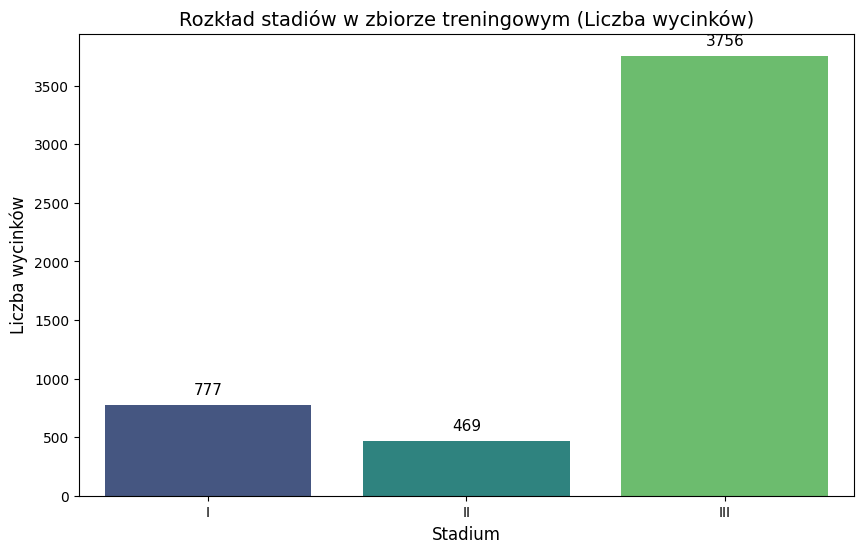


--- Przykładowe wycinki dla poszczególnych klas ---


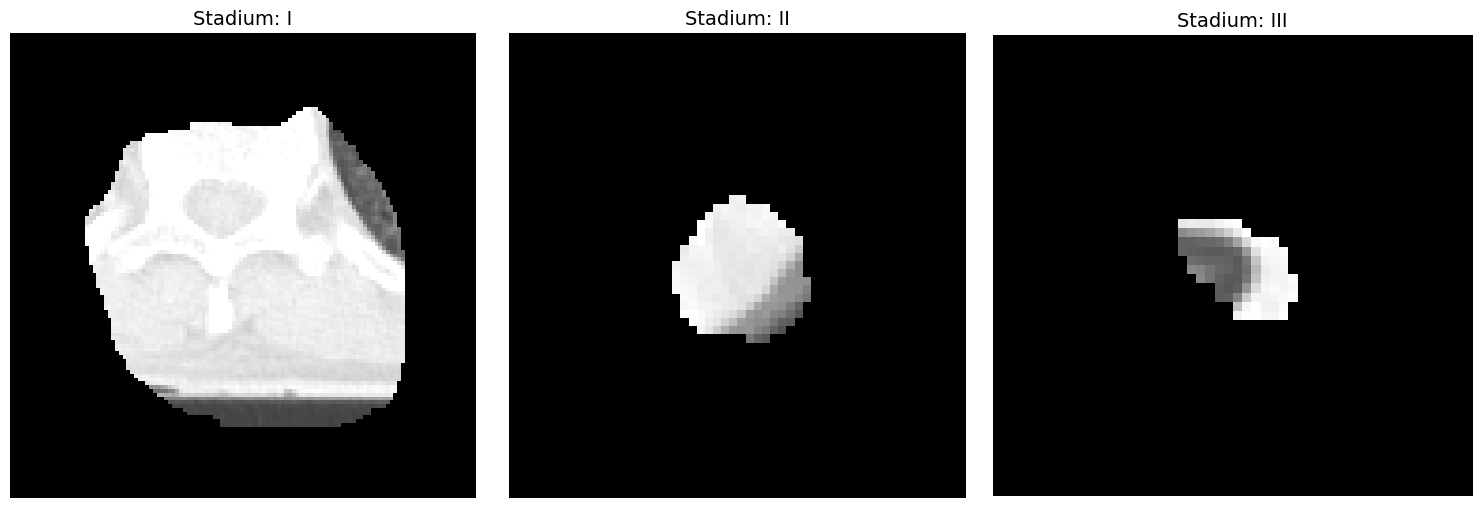

In [6]:
# Ścieżka do wypakowanego pliku train.csv
TRAIN_CSV = '/content/dataset_masked/train.csv'

df_train = pd.read_csv(TRAIN_CSV)
df_train['merged_stage'] = df_train['original_stage'].replace({'IIIa': 'III', 'IIIb': 'III'})

# Statystyki klas w zbiorze treningowym
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')
plt.title('Rozkład stadiów w zbiorze treningowym (Liczba wycinków)', fontsize=14)
plt.xlabel('Stadium', fontsize=12)
plt.ylabel('Liczba wycinków', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# Wizualizacja przykładowych zdjęć dla każdej z 3 klas po połączeniu IIIa i IIIb
print("\n--- Przykładowe wycinki dla poszczególnych klas ---")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
stages = ['I', 'II', 'III']

for i, stage in enumerate(stages):
    sample_img_path = df_train[df_train['merged_stage'] == stage].iloc[0]['image_path']

    clean_path = sample_img_path.replace('\\', '/')
    filename = os.path.basename(clean_path)

    colab_img_path = os.path.join('/content/dataset_masked/data_2d_masked_ct', filename)

    img = Image.open(colab_img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Stadium: {stage}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

EDA dla datasetu - demografia pacjentów, typy histologiczne i podział slice'ów pomiędzy pacjentami

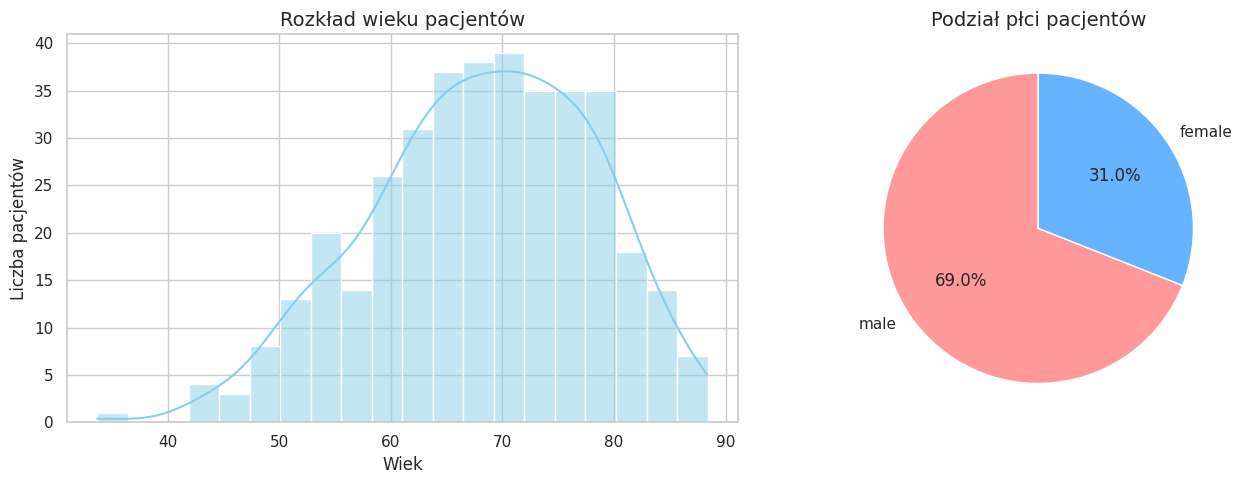

/tmp/ipykernel_1472/624192595.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')


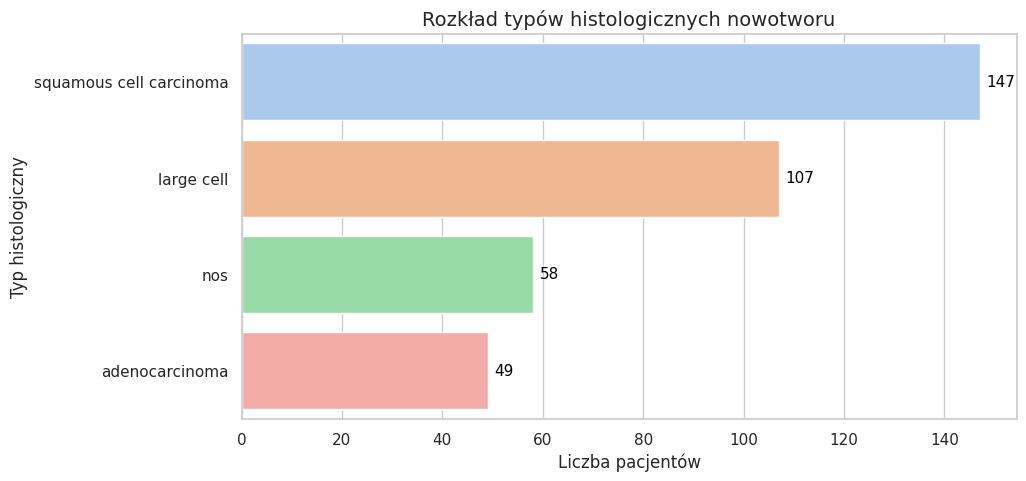

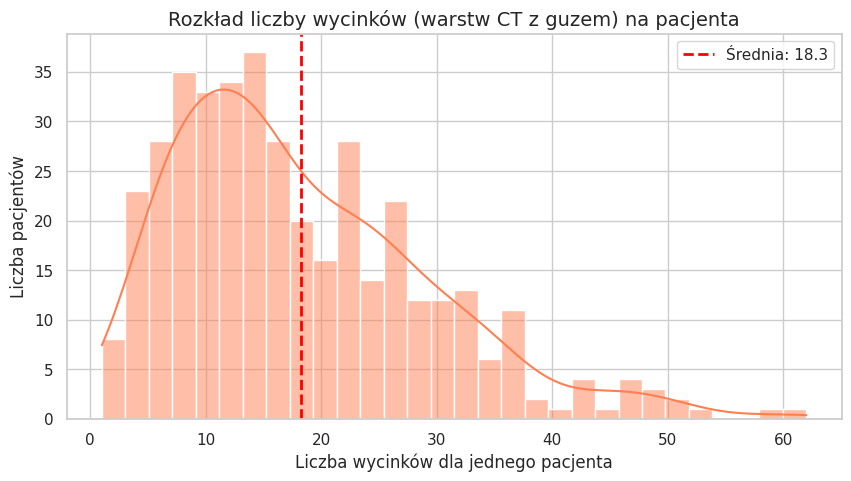

Całkowita liczba uwzględnionych pacjentów: 400
Średni wiek pacjenta: 68.1 lat (Min: 34, Max: 88)
Średnia liczba wycinków na pacjenta: 18.3
Pacjent z najmniejszą liczbą wycinków ma ich: 1
Pacjent z największą liczbą wycinków ma ich: 62


In [7]:

MASTER_CSV = r"/content/dataset_masked/master_dataset.csv"
CLINICAL_CSV = r"/content/dataset_masked/NSCLC-Radiomics-Lung1.clinical-data.csv"

df_master = pd.read_csv(MASTER_CSV)
df_clinical = pd.read_csv(CLINICAL_CSV)

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()
df_master['patient_id'] = df_master['patient_id'].astype(str).str.strip()

df_merged = df_master[['patient_id']].drop_duplicates().merge(
    df_clinical, left_on='patient_id', right_on='PatientID', how='inner'
)

sns.set_theme(style="whitegrid")

# Demografia (Wiek i Płeć)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(data=df_merged, x='age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Rozkład wieku pacjentów', fontsize=14)
axes[0].set_xlabel('Wiek', fontsize=12)
axes[0].set_ylabel('Liczba pacjentów', fontsize=12)

gender_col = 'gender' if 'gender' in df_merged.columns else 'Gender' if 'Gender' in df_merged.columns else None

if gender_col:
    gender_counts = df_merged[gender_col].value_counts()
    axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                startangle=90, colors=['#ff9999','#66b3ff'])
    axes[1].set_title('Podział płci pacjentów', fontsize=14)

plt.tight_layout()
plt.show()

# Typy Histologiczne
histology_col = 'Histology' if 'Histology' in df_merged.columns else 'histology' if 'histology' in df_merged.columns else None

if histology_col:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')
    plt.title('Rozkład typów histologicznych nowotworu', fontsize=14)
    plt.xlabel('Liczba pacjentów', fontsize=12)
    plt.ylabel('Typ histologiczny', fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), textcoords='offset points')
    plt.show()

# Rozkład liczby warstw (wycinków) na pacjenta
plt.figure(figsize=(10, 5))
slices_per_patient = df_master.groupby('patient_id').size()

sns.histplot(slices_per_patient, bins=30, kde=True, color='coral')
plt.title('Rozkład liczby wycinków (warstw CT z guzem) na pacjenta', fontsize=14)
plt.xlabel('Liczba wycinków dla jednego pacjenta', fontsize=12)
plt.ylabel('Liczba pacjentów', fontsize=12)

mean_slices = slices_per_patient.mean()
plt.axvline(mean_slices, color='red', linestyle='dashed', linewidth=2, label=f'Średnia: {mean_slices:.1f}')
plt.legend()
plt.show()

print(f"Całkowita liczba uwzględnionych pacjentów: {len(df_merged)}")
print(f"Średni wiek pacjenta: {df_merged['age'].mean():.1f} lat (Min: {df_merged['age'].min():.0f}, Max: {df_merged['age'].max():.0f})")
print(f"Średnia liczba wycinków na pacjenta: {mean_slices:.1f}")
print(f"Pacjent z najmniejszą liczbą wycinków ma ich: {slices_per_patient.min()}")
print(f"Pacjent z największą liczbą wycinków ma ich: {slices_per_patient.max()}")

# PROTO - dodanie wieku i innych cech:



In [8]:
# Wczytanie i przygotowanie metadanych klinicznych
df_clinical = pd.read_csv('/content/dataset_masked/NSCLC-Radiomics-Lung1.clinical-data.csv')

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()

# Wczytanie pacjentów tylko ze zbioru treningowego
df_train_for_leak = pd.read_csv('/content/dataset_masked/train.csv')
train_patient_ids = df_train_for_leak['patient_id'].astype(str).str.strip().unique()

train_clinical = df_clinical[df_clinical['PatientID'].isin(train_patient_ids)]
age_mean = train_clinical['age'].mean()
age_std = train_clinical['age'].std()

# Aplikacja normalizacji na WSZYSTKICH pacjentów (Train, Val, Test) używając parametrów treningowych
df_clinical['age_norm'] = (df_clinical['age'] - age_mean) / age_std

df_clinical['gender_bin'] = df_clinical['gender'].map({'male': 0.0, 'female': 1.0}).fillna(0.0)
clinical_features = df_clinical[['PatientID', 'age_norm', 'gender_bin']]

Preprocessing do ResNet

In [19]:
import torchvision.transforms as transforms

IMAGE_SIZE = 224

# Przekształcenia dla zbioru treningowego z augumentacją danych
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08))
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms dla masked CT gotowe!")

Transforms dla masked CT gotowe!


Klasa Dataset

In [20]:
class LungCancerHybridDataset(Dataset):
    def __init__(self, csv_file, clinical_df, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Merge z danymi klinicznymi
        self.data_frame = self.data_frame.merge(
            clinical_df[['PatientID', 'age_norm', 'gender_bin']],
            left_on='patient_id', right_on='PatientID', how='left'
        )

        self.data_frame['age_norm'] = self.data_frame['age_norm'].fillna(0.0)
        self.data_frame['gender_bin'] = self.data_frame['gender_bin'].fillna(0.0)

        # Mapowanie etykiet
        label_col = 'original_stage' if 'original_stage' in self.data_frame.columns else 'label'
        self.data_frame['merged_label'] = self.data_frame[label_col].apply(merge_stage_label)

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]

        # Obraz
        filename = os.path.basename(row['image_path'].replace('\\', '/'))
        img_path = os.path.join(self.root_dir, filename)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Dane kliniczne (Wiek, Płeć)
        clinical_vec = torch.tensor([row['age_norm'], row['gender_bin']], dtype=torch.float32)

        # Etykieta
        label = int(row['merged_label'])

        return image, clinical_vec, label



DataLoaders i WeightedSampler


In [21]:
from posix import truncate
from sklearn.utils.class_weight import compute_class_weight
IMG_DIR_COLAB = '/content/dataset_masked/data_2d_masked_ct'

# Tworzenie instancji hybrydowych datasetów
train_dataset = LungCancerHybridDataset(csv_file='/content/dataset_masked/train.csv',
                                        clinical_df=clinical_features,
                                        root_dir=IMG_DIR_COLAB,
                                        transform=train_transforms)

val_dataset = LungCancerHybridDataset(csv_file='/content/dataset_masked/val.csv',
                                      clinical_df=clinical_features,
                                      root_dir=IMG_DIR_COLAB,
                                      transform=val_test_transforms)

test_dataset = LungCancerHybridDataset(csv_file='/content/dataset_masked/test.csv',
                                       clinical_df=clinical_features,
                                       root_dir=IMG_DIR_COLAB,
                                       transform=val_test_transforms)

# Weighted Sampler - Balansowanie klas I, II, III
train_labels = train_dataset.data_frame['merged_label'].values
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = torch.from_numpy(class_weights[train_labels]).type(torch.DoubleTensor)

CT_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# OBLICZENIE WAG DLA FUNKCJI STRATY
# Używamy dokładnie tej nazwy kolumny, którą miałeś w samplerze: 'merged_label'
train_labels_for_loss = train_dataset.data_frame['merged_label'].values

computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_for_loss),
    y=train_labels_for_loss
)

print(f"\nWyliczone wagi klas dla Loss Function (I, II, III): {computed_weights}")

# Weryfikacja
sample_batch = next(iter(train_loader))
print(f"Batch obrazów: {sample_batch[0].shape}")
print(f"Batch danych klinicznych: {sample_batch[1].shape}") # Powinno być [32, 2]
print(f"Batch etykiet: {sample_batch[2].shape}")
print("\nDane gotowe do treningu hybrydowego!")


Wyliczone wagi klas dla Loss Function (I, II, III): [2.14586015 3.55508173 0.44391196]
Batch obrazów: torch.Size([32, 3, 224, 224])
Batch danych klinicznych: torch.Size([32, 2])
Batch etykiet: torch.Size([32])

Dane gotowe do treningu hybrydowego!


Focal Loss

In [22]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt      = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

Trening ResNet- 18

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

class ResNetHybrid(nn.Module):
    def __init__(self, num_classes=3, hidden_units=512, dropout_rate=0.4):
        super(ResNetHybrid, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs + 2, hidden_units),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_units, num_classes)
        )

    def forward(self, img, clinical):
        img_features = self.backbone(img)
        combined     = torch.cat((img_features, clinical), dim=1)
        return self.classifier(combined)

# model = ResNetHybrid(num_classes=3, dropout_rate=0.4)

# for param in model.parameters():
#     param.requires_grad = False
# for param in model.backbone.layer3.parameters():
#     param.requires_grad = True
# for param in model.backbone.layer4.parameters():
#     param.requires_grad = True
# for param in model.classifier.parameters():
#     param.requires_grad = True

# model = model.to(device)

# train_labels  = train_dataset.data_frame['merged_label'].values
# class_counts  = np.bincount(train_labels)
# soft_weights  = 1.0 / np.sqrt(class_counts)
# soft_weights  = soft_weights / soft_weights.sum() * 3
# weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)
# criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# optimizer = optim.Adam([
#     {'params': model.backbone.layer3.parameters(), 'lr': 1e-6},
#     {'params': model.backbone.layer4.parameters(), 'lr': 5e-6},
#     {'params': model.classifier.parameters(),      'lr': 1e-3}
# ], weight_decay=1e-3)

# print("Setup: Baseline CrossEntropy gotowy!")

Używane urządzenie: cuda


Pętla ucząca

In [ ]:
# konfiguracja treninigu
target_names = ['Stadium I', 'Stadium II', 'Stadium III']
best_auc = 0.0
best_f1 = 0.0
best_acc = 0.0
results_path = 'best_metrics.txt'

with open(results_path, 'w') as f:
    f.write("REKORDY MODELU HYBRYDOWEGO (NSCLC STAGING)\n")


history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_auc': [], 'val_auc': []
}

NUM_EPOCHS = 20

# --- KONFIGURACJA EARLY STOPPING ---
patience = 10
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f'Epoka {epoch+1}/{NUM_EPOCHS}')

    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        dataloader = train_loader if phase == 'train' else val_loader

        running_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []

        for inputs, clinical_data, labels in dataloader:
            inputs, clinical_data, labels = inputs.to(device), clinical_data.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs, clinical_data)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            epoch_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except:
            epoch_auc = 0.0

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)
        history[f'{phase}_f1'].append(epoch_f1)
        history[f'{phase}_auc'].append(epoch_auc)

        print(f'{phase.upper()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | F1: {epoch_f1:.4f} | AUC: {epoch_auc:.4f}')

        if phase == 'val':
            if epoch_acc > best_acc:
                best_acc = epoch_acc

            # Rejestrowanie rekordu AUC (bez zapisu modelu)
            if epoch_auc > best_auc:
                best_auc = epoch_auc
                print(f"*** Nowy rekord AUC: {best_auc:.4f} ***")

            # Zapis modelu i Early Stopping na podstawie F1
            if epoch_f1 > best_f1:
                best_f1 = epoch_f1
                torch.save(model.state_dict(), 'best_hybrid_f1.pth')
                print(f"*** Zapisano model (Nowy rekord F1: {best_f1:.4f}) ***")
                epochs_no_improve = 0  # Resetujemy licznik cierpliwości
            else:
                epochs_no_improve += 1

    # Sprawdzenie warunku Early Stopping po zakończeniu obu faz (train i val) w epoce
    if epochs_no_improve >= patience:
        print(f"\n[Early Stopping] Brak poprawy F1 od {patience} epok. Przerwano trening.")
        break

    print()

# Ewaluacja
print("\nRaport klasyfikacji")

# WAŻNE: Wczytujemy model zapisany na podstawie najlepszego wyniku F1
model.load_state_dict(torch.load('best_hybrid_f1.pth'))
model.eval()

final_preds, final_labels, final_probs = [], [], []

with torch.no_grad():
    for inputs, clinical_data, labels in val_loader:
        inputs, clinical_data = inputs.to(device), clinical_data.to(device)
        outputs = model(inputs, clinical_data)

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        final_preds.extend(preds.cpu().numpy())
        final_labels.extend(labels.cpu().numpy())
        final_probs.extend(probs.cpu().numpy())

final_auc = roc_auc_score(final_labels, final_probs, multi_class='ovr', average='macro')
final_acc = accuracy_score(final_labels, final_preds)

print(f"\nOstateczny wynik AUC: {final_auc:.4f}")
print(f"Ostateczny wynik Acc: {final_acc:.4f}")
print(f"Referencyjny wynik z publikacji (RF): 0.881")
print("\nSzczegółowy raport klasyfikacji:")
print(classification_report(final_labels, final_preds, target_names=target_names))

cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek (Final AUC: {final_auc:.4f} | Acc: {final_acc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()

# Soft-voting na poziomie pacjentów

df_val_results = val_dataset.data_frame.copy()

df_val_results['prob_I'] = [p[0] for p in final_probs]
df_val_results['prob_II'] = [p[1] for p in final_probs]
df_val_results['prob_III'] = [p[2] for p in final_probs]
df_val_results['true_label'] = final_labels

patient_level_df = df_val_results.groupby('patient_id').agg({
    'prob_I': 'mean',
    'prob_II': 'mean',
    'prob_III': 'mean',
    'true_label': 'first'
}).reset_index()

patient_probs = patient_level_df[['prob_I', 'prob_II', 'prob_III']].values
patient_preds = np.argmax(patient_probs, axis=1)
patient_true = patient_level_df['true_label'].values

patient_acc = accuracy_score(patient_true, patient_preds)
patient_auc = roc_auc_score(patient_true, patient_probs, multi_class='ovr', average='macro')

print(" Wyniki soft-voting na zbiorze walidacyjnym")
print(" (Agregacja 2D -> 3D za pomocą Soft Voting)")
print(f"PATIENT AUC: {patient_auc:.4f} (Wynik referencyjny z publikacji: 0.881)")
print(f"PATIENT ACC: {patient_acc:.4f}")
print(classification_report(patient_true, patient_preds, target_names=target_names))

cm_patient = confusion_matrix(patient_true, patient_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek - Pacjenci (Patient AUC: {patient_auc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()

Epoka 1/20
TRAIN Loss: 0.9749 | Acc: 0.6957 | F1: 0.4243 | AUC: 0.6238
VAL Loss: 0.8119 | Acc: 0.6738 | F1: 0.3894 | AUC: 0.7319
*** Nowy rekord AUC: 0.7319 ***
*** Zapisano model (Nowy rekord F1: 0.3894) ***

Epoka 2/20
TRAIN Loss: 0.8947 | Acc: 0.7379 | F1: 0.4769 | AUC: 0.6970
VAL Loss: 0.7718 | Acc: 0.7216 | F1: 0.4873 | AUC: 0.7639
*** Nowy rekord AUC: 0.7639 ***
*** Zapisano model (Nowy rekord F1: 0.4873) ***

Epoka 3/20
TRAIN Loss: 0.8556 | Acc: 0.7417 | F1: 0.5055 | AUC: 0.7330
VAL Loss: 0.7405 | Acc: 0.7438 | F1: 0.4384 | AUC: 0.7597

Epoka 4/20
TRAIN Loss: 0.8391 | Acc: 0.7541 | F1: 0.5383 | AUC: 0.7350
VAL Loss: 0.7423 | Acc: 0.7293 | F1: 0.4863 | AUC: 0.7529

Epoka 5/20


KeyboardInterrupt: 

Krzywa uczenia i straty

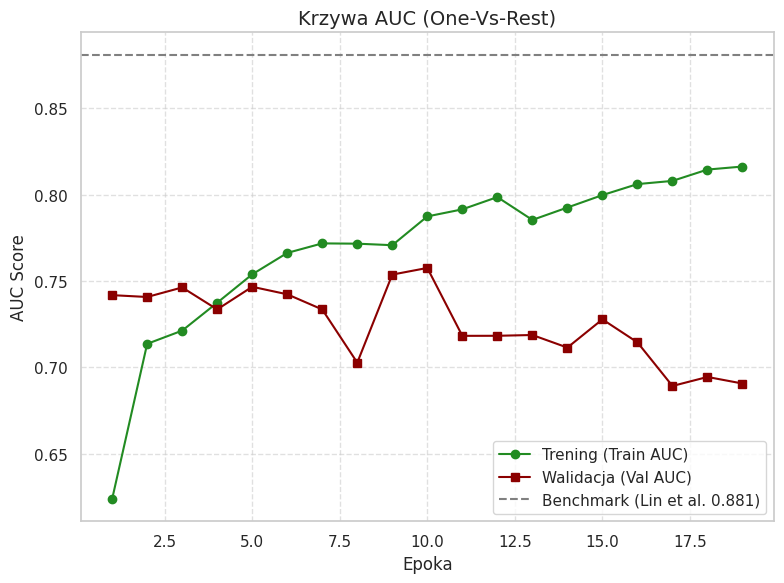

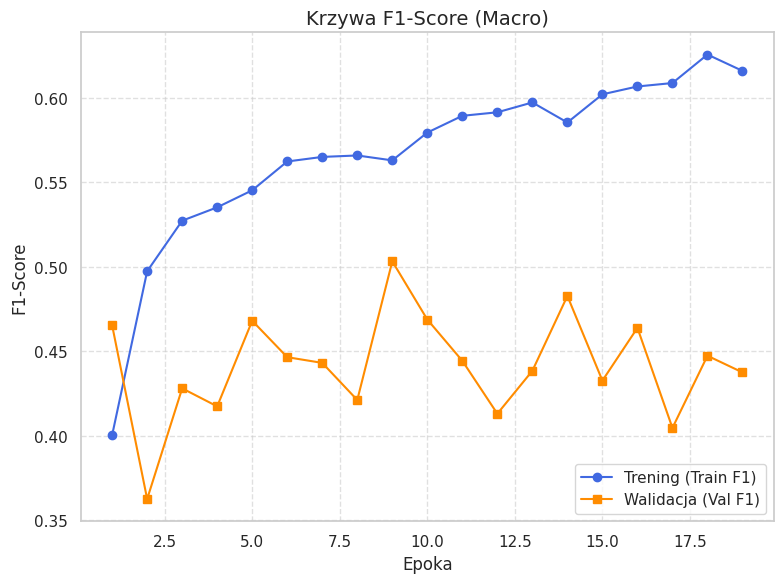

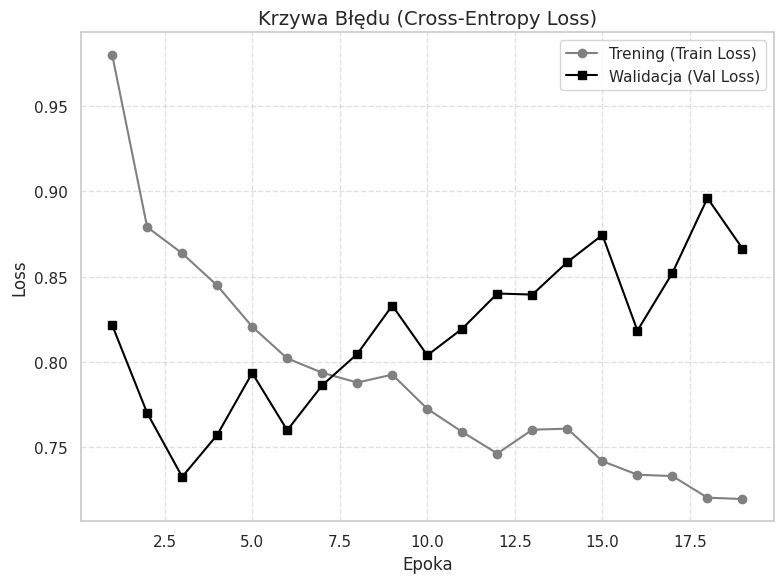

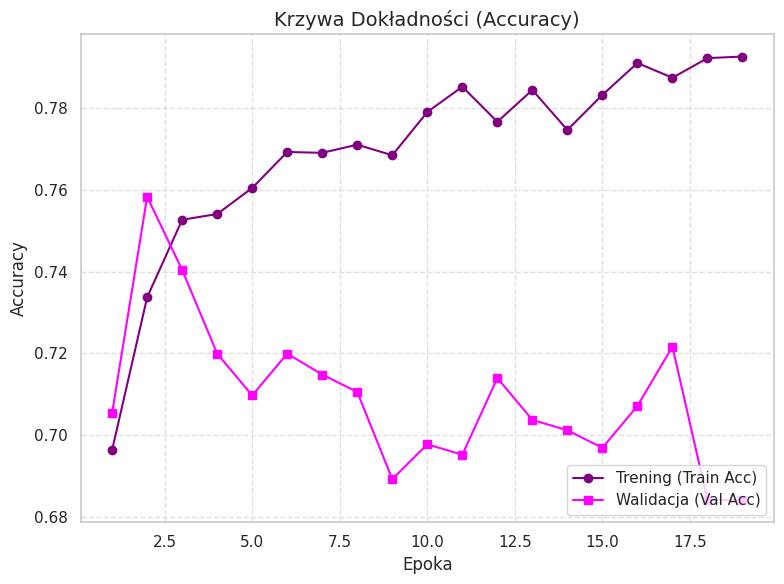

In [ ]:
epochs_range = range(1, len(history['train_f1']) + 1)

#  AUC
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_auc', [0]*len(epochs_range)), label='Trening (Train AUC)', marker='o', color='forestgreen')
plt.plot(epochs_range, history.get('val_auc', [0]*len(epochs_range)), label='Walidacja (Val AUC)', marker='s', color='darkred')
plt.axhline(y=0.881, color='gray', linestyle='--', label='Benchmark (Lin et al. 0.881)')
plt.title('Krzywa AUC (One-Vs-Rest)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_auc.png', dpi=300, bbox_inches='tight')
plt.show()


# F1-Score (Macro Average)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_f1'], label='Trening (Train F1)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_f1'], label='Walidacja (Val F1)', marker='s', color='darkorange')
plt.title('Krzywa F1-Score (Macro)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# Funkcja błędu (Loss)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_loss', [0]*len(epochs_range)), label='Trening (Train Loss)', marker='o', color='gray')
plt.plot(epochs_range, history.get('val_loss', [0]*len(epochs_range)), label='Walidacja (Val Loss)', marker='s', color='black')
plt.title('Krzywa Błędu (Cross-Entropy Loss)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Accuracy (Dokładność)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_acc', [0]*len(epochs_range)), label='Trening (Train Acc)', marker='o', color='purple')
plt.plot(epochs_range, history.get('val_acc', [0]*len(epochs_range)), label='Walidacja (Val Acc)', marker='s', color='magenta')
plt.title('Krzywa Dokładności (Accuracy)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

Grad-Cam

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


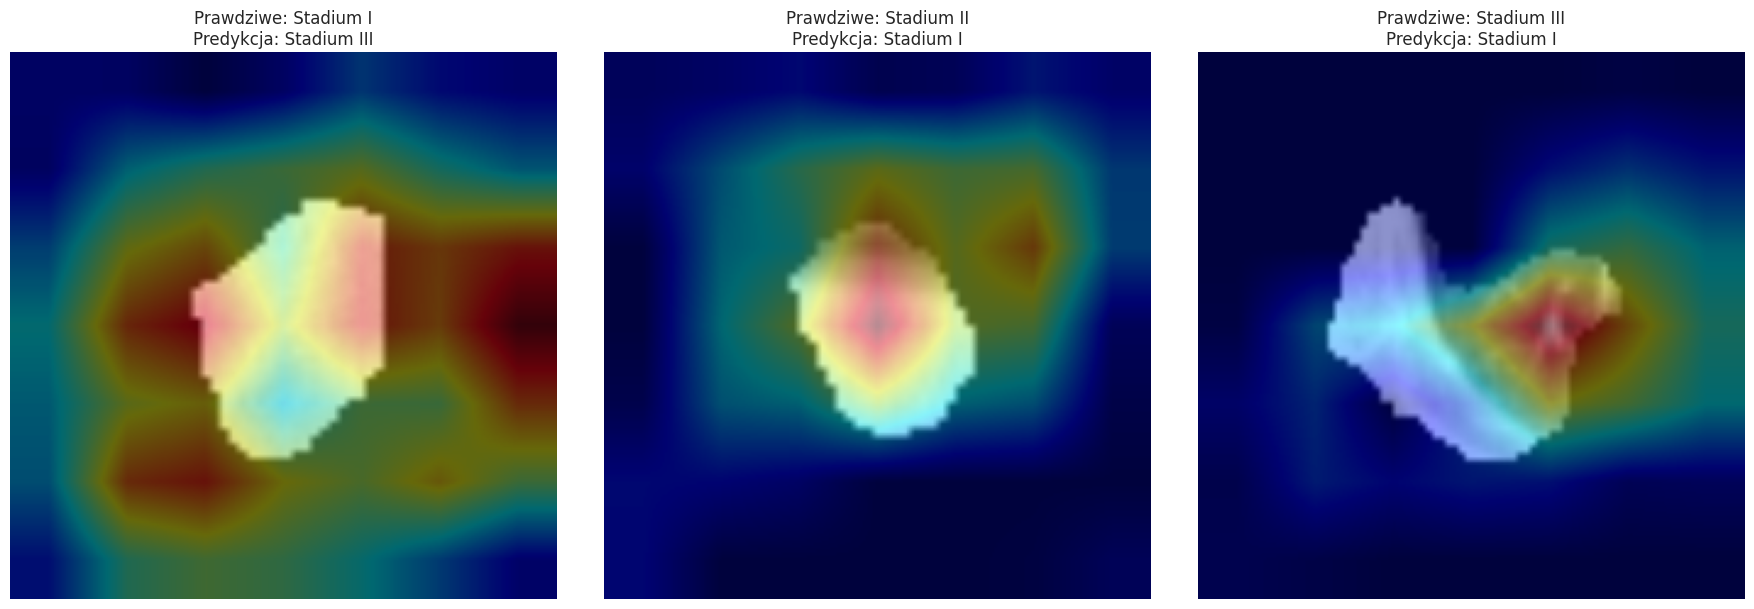

In [ ]:
def generate_gradcam(model, input_img, clinical_data, target_layer):
    model.eval()

    feature_blobs = []
    gradients = []

    def hook_feature(module, input, output):
        feature_blobs.append(output.cpu().data.numpy())

    def hook_gradient(module, grad_input, grad_output):
        gradients.append(grad_output[0].cpu().data.numpy())

    handle_forward = target_layer.register_forward_hook(hook_feature)
    handle_backward = target_layer.register_backward_hook(hook_gradient)

    output = model(input_img, clinical_data)
    _, target_class = torch.max(output, 1)

    model.zero_grad()
    output[0, target_class].backward()

    # Wyznaczanie wag i mapy ciepła
    grads = gradients[0]
    weights = np.mean(grads, axis=(2, 3))[0]
    features = feature_blobs[0][0]

    cam = np.zeros(features.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * features[i, :, :]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))

    handle_forward.remove()
    handle_backward.remove()

    return cam, target_class.item()

def show_gradcam_gallery(model, dataset):
    # Szukamy po jednym przykładzie dla każdego stadium (0, 1, 2)
    indices = []
    for target_label in [0, 1, 2]:
        for i in range(len(dataset)):
            _, _, label = dataset[i]
            if label == target_label:
                indices.append(i)
                break

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    target_names = ['Stadium I', 'Stadium II', 'Stadium III']

    for i, idx in enumerate(indices):
        img_tensor, clinical_tensor, label = dataset[idx]

        input_img = img_tensor.unsqueeze(0).to(device)
        clinical_data = clinical_tensor.unsqueeze(0).to(device)

        heatmap, pred_class = generate_gradcam(model, input_img, clinical_data, model.backbone.layer4)

        img_show = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())

        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.6 * img_show + 0.4 * heatmap_color

        axes[i].imshow(overlay)
        axes[i].set_title(f"Prawdziwe: {target_names[label]}\nPredykcja: {target_names[pred_class]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Wywołanie
show_gradcam_gallery(model, val_dataset)

# Optuna


Tutaj celujemy w usprawnienie AUC jako metryki dla slice'ów

In [30]:
def save_callback(study, trial):
    if trial.state.name == "COMPLETE":
        print(f"\n✓ Trial {trial.number} | AUC: {trial.value:.4f} | Najlepszy: {study.best_value:.4f}")
        with open(f'{DRIVE_SAVE_DIR}/best_optuna_params_masked_focal.json', 'w') as fp:
            json.dump(study.best_params, fp, indent=2)
        import shutil
        shutil.copy(
            '/content/best_optuna_params_masked_focal.db',
            f'{DRIVE_SAVE_DIR}/best_optuna_params_masked_focal.db'
        )

In [31]:
import optuna
import json
import numpy as np
import torch
import torch.optim as optim
from sklearn.metrics import f1_score, roc_auc_score

EPOCHS_PER_TRIAL = 20

def objective(trial):
    gamma        = trial.suggest_float("gamma",        1.3,  1.7)
    lr_fc        = trial.suggest_float("lr_fc",        8e-4, 2e-3, log=True)
    lr_layer4    = trial.suggest_float("lr_layer4",    3e-6, 2e-5, log=True)
    lr_layer3    = trial.suggest_float("lr_layer3",    5e-7, 8e-6, log=True)
    weight_decay = trial.suggest_float("weight_decay", 5e-4, 5e-3, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.30, 0.50)

    model = ResNetHybrid(num_classes=3, dropout_rate=dropout_rate).to(device)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.backbone.layer3.parameters():
        param.requires_grad = True
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    train_labels   = train_dataset.data_frame['merged_label'].values
    class_counts   = np.bincount(train_labels)
    soft_weights   = 1.0 / np.sqrt(class_counts)
    soft_weights   = soft_weights / soft_weights.sum() * 3
    weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)

    criterion = FocalLoss(gamma=gamma, weight=weights_tensor)

    optimizer = optim.Adam([
        {'params': model.backbone.layer3.parameters(), 'lr': lr_layer3},
        {'params': model.backbone.layer4.parameters(), 'lr': lr_layer4},
        {'params': model.classifier.parameters(),      'lr': lr_fc}
    ], weight_decay=weight_decay)

    best_trial_auc = 0.0

    for epoch in range(EPOCHS_PER_TRIAL):
        model.train()
        for inputs, clinical_data, labels in train_loader:
            inputs        = inputs.to(device)
            clinical_data = clinical_data.to(device)
            labels        = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs, clinical_data)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        all_labels, all_preds, all_probs = [], [], []

        with torch.no_grad():
            for inputs, clinical_data, labels in val_loader:
                inputs        = inputs.to(device)
                clinical_data = clinical_data.to(device)
                outputs       = model(inputs, clinical_data)
                probs         = torch.softmax(outputs, dim=1)
                _, preds      = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        try:
            val_auc = roc_auc_score(all_labels, all_probs,
                                     multi_class='ovr', average='macro')
        except:
            val_auc = 0.0

        if val_auc > best_trial_auc:
            best_trial_auc = val_auc

        print(f"  Trial {trial.number} | E{epoch+1:02} | AUC: {val_auc:.4f} | Best: {best_trial_auc:.4f}")

        trial.report(val_auc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_trial_auc


def save_callback(study, trial):
    if trial.state.name == "COMPLETE":
        print(f"\n✓ Trial {trial.number} | AUC: {trial.value:.4f} | Najlepszy: {study.best_value:.4f}")
        with open('/content/drive/MyDrive/masked_ct_models/best_optuna_params_masked_focal.json', 'w') as fp:
            json.dump(study.best_params, fp, indent=2)


study = optuna.create_study(
    direction="maximize",
    study_name="ResNetHybrid_Masked_Focal_NoBlur_V1",
    storage="sqlite:////content/optuna_masked_focal_noblur_v1.db",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)

print(f"Triali w bazie: {len(study.trials)}")

study.optimize(
    objective,
    n_trials=20,
    timeout=36000,
    callbacks=[save_callback]
)

print(f"\nNajlepszy AUC: {study.best_value:.4f}")
print("Najlepsze parametry:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

with open('/content/drive/MyDrive/masked_ct_models/best_optuna_params_masked_focal.json', 'w') as fp:
    json.dump(study.best_params, fp, indent=2)
print("\nParametry zapisane.")

[I 2026-04-26 13:44:00,911] Using an existing study with name 'ResNetHybrid_Masked_Focal_NoBlur_V1' instead of creating a new one.


Triali w bazie: 2
  Trial 2 | E01 | AUC: 0.7272 | Best: 0.7272
  Trial 2 | E02 | AUC: 0.7137 | Best: 0.7272
  Trial 2 | E03 | AUC: 0.7202 | Best: 0.7272
  Trial 2 | E04 | AUC: 0.7003 | Best: 0.7272
  Trial 2 | E05 | AUC: 0.7075 | Best: 0.7272
  Trial 2 | E06 | AUC: 0.6889 | Best: 0.7272
  Trial 2 | E07 | AUC: 0.6755 | Best: 0.7272
  Trial 2 | E08 | AUC: 0.6948 | Best: 0.7272
  Trial 2 | E09 | AUC: 0.6872 | Best: 0.7272
  Trial 2 | E10 | AUC: 0.6804 | Best: 0.7272
  Trial 2 | E11 | AUC: 0.6679 | Best: 0.7272
  Trial 2 | E12 | AUC: 0.6737 | Best: 0.7272
  Trial 2 | E13 | AUC: 0.6556 | Best: 0.7272
  Trial 2 | E14 | AUC: 0.6632 | Best: 0.7272
  Trial 2 | E15 | AUC: 0.6489 | Best: 0.7272
  Trial 2 | E16 | AUC: 0.6590 | Best: 0.7272
  Trial 2 | E17 | AUC: 0.6629 | Best: 0.7272
  Trial 2 | E18 | AUC: 0.6737 | Best: 0.7272
  Trial 2 | E19 | AUC: 0.6249 | Best: 0.7272


[I 2026-04-26 13:47:47,267] Trial 2 finished with value: 0.7271689689105371 and parameters: {'gamma': 1.3895565870950335, 'lr_fc': 0.0009282860332858614, 'lr_layer4': 4.70311084805555e-06, 'lr_layer3': 1.7691864029074115e-06, 'weight_decay': 0.000552823890370629, 'dropout_rate': 0.3118905590338909}. Best is trial 2 with value: 0.7271689689105371.


  Trial 2 | E20 | AUC: 0.6474 | Best: 0.7272

✓ Trial 2 | AUC: 0.7272 | Najlepszy: 0.7272
  Trial 3 | E01 | AUC: 0.6915 | Best: 0.6915
  Trial 3 | E02 | AUC: 0.6872 | Best: 0.6915
  Trial 3 | E03 | AUC: 0.6649 | Best: 0.6915
  Trial 3 | E04 | AUC: 0.6527 | Best: 0.6915
  Trial 3 | E05 | AUC: 0.6438 | Best: 0.6915
  Trial 3 | E06 | AUC: 0.6427 | Best: 0.6915
  Trial 3 | E07 | AUC: 0.6402 | Best: 0.6915
  Trial 3 | E08 | AUC: 0.6521 | Best: 0.6915
  Trial 3 | E09 | AUC: 0.6545 | Best: 0.6915
  Trial 3 | E10 | AUC: 0.6378 | Best: 0.6915
  Trial 3 | E11 | AUC: 0.6405 | Best: 0.6915
  Trial 3 | E12 | AUC: 0.6241 | Best: 0.6915
  Trial 3 | E13 | AUC: 0.5942 | Best: 0.6915
  Trial 3 | E14 | AUC: 0.6018 | Best: 0.6915
  Trial 3 | E15 | AUC: 0.6080 | Best: 0.6915
  Trial 3 | E16 | AUC: 0.6039 | Best: 0.6915
  Trial 3 | E17 | AUC: 0.5822 | Best: 0.6915
  Trial 3 | E18 | AUC: 0.6035 | Best: 0.6915
  Trial 3 | E19 | AUC: 0.5991 | Best: 0.6915


[I 2026-04-26 13:51:32,927] Trial 3 finished with value: 0.6915332114180721 and parameters: {'gamma': 1.6830109096049979, 'lr_fc': 0.001408486269547413, 'lr_layer4': 1.6218526470973035e-05, 'lr_layer3': 6.97058297154931e-07, 'weight_decay': 0.0023367236635508395, 'dropout_rate': 0.4477977093367208}. Best is trial 2 with value: 0.7271689689105371.


...

  Trial 19 | E20 | AUC: 0.6159 | Best: 0.7553

✓ Trial 19 | AUC: 0.7553 | Najlepszy: 0.7553
  Trial 20 | E01 | AUC: 0.6579 | Best: 0.6579
  Trial 20 | E02 | AUC: 0.6784 | Best: 0.6784
  Trial 20 | E03 | AUC: 0.7061 | Best: 0.7061
  Trial 20 | E04 | AUC: 0.6719 | Best: 0.7061
  Trial 20 | E05 | AUC: 0.6697 | Best: 0.7061
  Trial 20 | E06 | AUC: 0.6248 | Best: 0.7061
  Trial 20 | E07 | AUC: 0.6649 | Best: 0.7061
  Trial 20 | E08 | AUC: 0.6674 | Best: 0.7061
  Trial 20 | E09 | AUC: 0.6356 | Best: 0.7061
  Trial 20 | E10 | AUC: 0.6400 | Best: 0.7061
  Trial 20 | E11 | AUC: 0.6499 | Best: 0.7061
  Trial 20 | E12 | AUC: 0.6659 | Best: 0.7061
  Trial 20 | E13 | AUC: 0.6035 | Best: 0.7061
  Trial 20 | E14 | AUC: 0.6220 | Best: 0.7061
  Trial 20 | E15 | AUC: 0.6572 | Best: 0.7061
  Trial 20 | E16 | AUC: 0.6315 | Best: 0.7061
  Trial 20 | E17 | AUC: 0.6191 | Best: 0.7061
  Trial 20 | E18 | AUC: 0.5892 | Best: 0.7061
  Trial 20 | E19 | AUC: 0.6421 | Best: 0.7061


[I 2026-04-26 14:55:23,117] Trial 20 finished with value: 0.7060572381471504 and parameters: {'gamma': 1.548682705653839, 'lr_fc': 0.0015036009469189494, 'lr_layer4': 1.5156763374652526e-05, 'lr_layer3': 5.711468810067802e-07, 'weight_decay': 0.0013373067806228662, 'dropout_rate': 0.3330807073744688}. Best is trial 19 with value: 0.755261990846018.


  Trial 20 | E20 | AUC: 0.6294 | Best: 0.7061

✓ Trial 20 | AUC: 0.7061 | Najlepszy: 0.7553
  Trial 21 | E01 | AUC: 0.6651 | Best: 0.6651
  Trial 21 | E02 | AUC: 0.6856 | Best: 0.6856
  Trial 21 | E03 | AUC: 0.6685 | Best: 0.6856
  Trial 21 | E04 | AUC: 0.6773 | Best: 0.6856
  Trial 21 | E05 | AUC: 0.6386 | Best: 0.6856
  Trial 21 | E06 | AUC: 0.6642 | Best: 0.6856
  Trial 21 | E07 | AUC: 0.6377 | Best: 0.6856
  Trial 21 | E08 | AUC: 0.6331 | Best: 0.6856
  Trial 21 | E09 | AUC: 0.6205 | Best: 0.6856
  Trial 21 | E10 | AUC: 0.6414 | Best: 0.6856
  Trial 21 | E11 | AUC: 0.6276 | Best: 0.6856
  Trial 21 | E12 | AUC: 0.6354 | Best: 0.6856
  Trial 21 | E13 | AUC: 0.6112 | Best: 0.6856
  Trial 21 | E14 | AUC: 0.6139 | Best: 0.6856
  Trial 21 | E15 | AUC: 0.6313 | Best: 0.6856
  Trial 21 | E16 | AUC: 0.5797 | Best: 0.6856
  Trial 21 | E17 | AUC: 0.6335 | Best: 0.6856
  Trial 21 | E18 | AUC: 0.5994 | Best: 0.6856
  Trial 21 | E19 | AUC: 0.5980 | Best: 0.6856


[I 2026-04-26 14:59:08,917] Trial 21 finished with value: 0.6856463576719841 and parameters: {'gamma': 1.6231670415598507, 'lr_fc': 0.0013326227540375686, 'lr_layer4': 1.9475403066268566e-05, 'lr_layer3': 5.212863930868116e-07, 'weight_decay': 0.0036152082629261526, 'dropout_rate': 0.37634694169291494}. Best is trial 19 with value: 0.755261990846018.


  Trial 21 | E20 | AUC: 0.5885 | Best: 0.6856

✓ Trial 21 | AUC: 0.6856 | Najlepszy: 0.7553

Najlepszy AUC: 0.7553
Najlepsze parametry:
  gamma: 1.5461193874061445
  lr_fc: 0.0015694954884747988
  lr_layer4: 1.4619478616188916e-05
  lr_layer3: 5.2720749096987e-07
  weight_decay: 0.0012886977292786823
  dropout_rate: 0.3319447425527677

Parametry zapisane.


Params warte uwagi:

[I 2026-04-25 20:57:56,482] Trial 12 finished with value: 0.7666462436053448 and parameters: {'lr_fc': 0.001550818708025384, 'lr_layer4': 6.082341230733749e-06, 'lr_layer3': 1.3714113867388413e-06, 'weight_decay': 0.002690462855005448, 'dropout_rate': 0.3744654920089184}. Best is trial 12 with value: 0.7666462436053448.

Finałowy trening oraz soft-voting

Urządzenie: cuda
Wczytane parametry (Masked CT Focal): {'gamma': 1.5461193874061445, 'lr_fc': 0.0015694954884747988, 'lr_layer4': 1.4619478616188916e-05, 'lr_layer3': 5.2720749096987e-07, 'weight_decay': 0.0012886977292786823, 'dropout_rate': 0.3319447425527677}

Wycinki w klasach (I, II, III): [ 777  469 3756]
Soft wagi: [1.0941 1.4083 0.4976]
Criterion: FocalLoss gamma=1.5461
Optimizer: Adam lr_layer3=5.27e-07 lr_layer4=1.46e-05 lr_fc=1.57e-03 weight_decay=1.29e-03

Epoka  T-Loss    V-Loss    V-AUC (slice)   PAT-AUC    PAT-F1    Best PAT-AUC
────────────────────────────────────────────────────────────────────────────────
E01   | 0.3252    0.3032    0.7155          0.7288     0.4269    0.0000
      ✓ Nowy rekord Patient AUC: 0.7288 — zapisano
      ✓ Nowy rekord Patient F1:  0.4269 — zapisano
E02   | 0.2775    0.3284    0.7254          0.7541     0.3958    0.7288
      ✓ Nowy rekord Patient AUC: 0.7541 — zapisano
E03   | 0.2631    0.2946    0.6944          0.7211     0.3961    0.7541


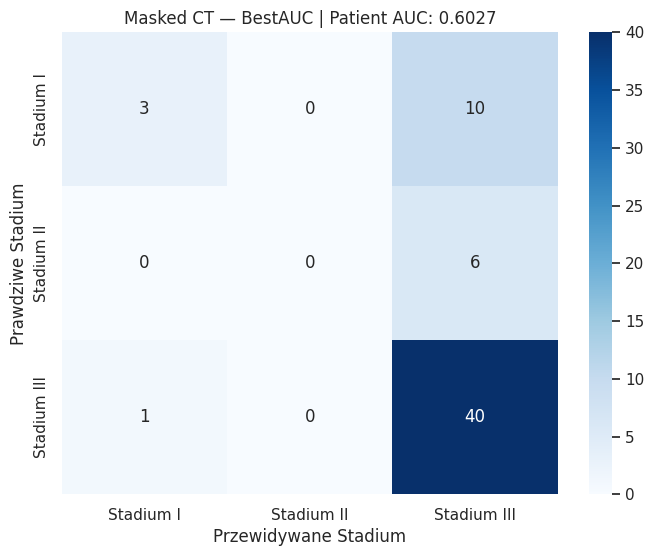

Zapisano: /content/drive/MyDrive/masked_ct_models/cm_masked_BestAUC.png

────────────────────────────────────────────────────────────
Ewaluacja: BestF1  (z TTA)
────────────────────────────────────────────────────────────
PATIENT AUC : 0.6519   (Benchmark: 0.881)
PATIENT F1  : 0.4857
PATIENT ACC : 0.6333

              precision    recall  f1-score   support

   Stadium I     0.3333    0.5385    0.4118        13
  Stadium II     1.0000    0.1667    0.2857         6
 Stadium III     0.7895    0.7317    0.7595        41

    accuracy                         0.6333        60
   macro avg     0.7076    0.4789    0.4857        60
weighted avg     0.7117    0.6333    0.6368        60



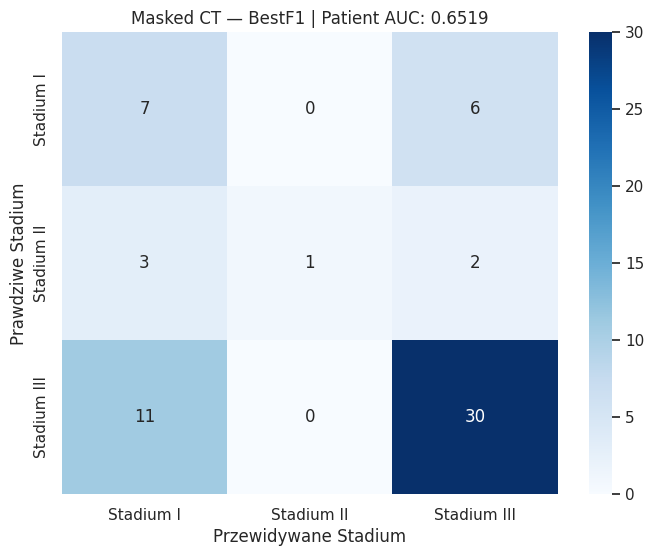

Zapisano: /content/drive/MyDrive/masked_ct_models/cm_masked_BestF1.png


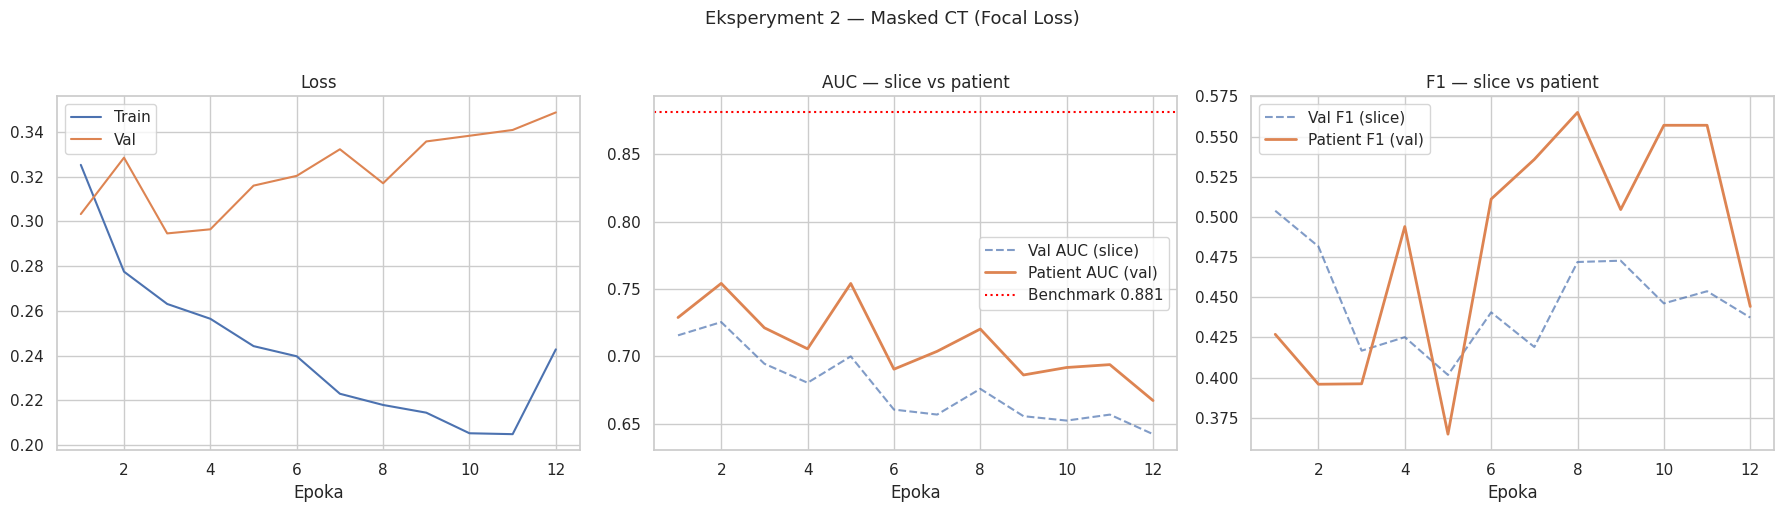

Historia treningu zapisana: /content/drive/MyDrive/masked_ct_models/training_history_masked_focal.png


In [32]:
"""
FINALNY TRENING — Eksperyment 2 (Masked CT) — v4
ResNetHybrid, Focal Loss, IMAGE_SIZE=224, best_params z Optuny dla Masked CT

Zmiany względem v3:
  1. Jawny setup modelu z wczytaniem best_optuna_params_masked_focal.json
  2. criterion = FocalLoss z parametrami z Optuny (nie dziedziczy z poprzedniej komórki)
  3. Optimizer z LR z Optuny
  4. Print potwierdzający konfigurację przed treningiem
"""

import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from torchvision import transforms as T

DRIVE_SAVE_DIR = '/content/drive/MyDrive/masked_ct_models'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────
# POMOCNICZA: Patient-level soft-voting
# ──────────────────────────────────────────────────────────────────────────────

def compute_patient_auc(model, dataset, device, transforms_fn=None):
    model.eval()
    all_probs, all_labels = [], []

    loader = torch.utils.data.DataLoader(
        dataset, batch_size=32, shuffle=False, num_workers=2
    )

    with torch.no_grad():
        for inputs, clinical, labels in loader:
            inputs   = inputs.to(device)
            clinical = clinical.to(device)
            outputs  = model(inputs, clinical)
            probs    = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    df = dataset.data_frame.copy()
    df['prob_I']     = [p[0] for p in all_probs]
    df['prob_II']    = [p[1] for p in all_probs]
    df['prob_III']   = [p[2] for p in all_probs]
    df['true_label'] = all_labels

    pat = (
        df.groupby('patient_id')
          .agg({'prob_I': 'mean', 'prob_II': 'mean',
                'prob_III': 'mean', 'true_label': 'first'})
          .reset_index()
    )

    probs_arr = pat[['prob_I', 'prob_II', 'prob_III']].values
    preds_arr = np.argmax(probs_arr, axis=1)
    true_arr  = pat['true_label'].values

    try:
        p_auc = roc_auc_score(
            true_arr, probs_arr,
            multi_class='ovr', average='macro', labels=[0, 1, 2]
        )
    except ValueError:
        p_auc = 0.0

    p_f1 = f1_score(true_arr, preds_arr, average='macro',
                    labels=[0, 1, 2], zero_division=0)

    return p_auc, p_f1, probs_arr, true_arr


def compute_patient_auc_tta(model, dataset, device, n_tta=5):
    tta_transform = T.Compose([
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=10),
        T.ColorJitter(brightness=0.1, contrast=0.1),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
    ])

    model.eval()
    df = dataset.data_frame.copy()
    sum_probs  = np.zeros((len(df), 3), dtype=np.float64)
    all_labels = []

    loader = torch.utils.data.DataLoader(
        dataset, batch_size=32, shuffle=False, num_workers=2
    )

    for aug_pass in range(n_tta):
        pass_probs = []

        with torch.no_grad():
            for inputs, clinical, labels in loader:
                if aug_pass > 0:
                    inv = T.Normalize(
                        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                        std=[1/0.229,       1/0.224,       1/0.225]
                    )
                    inputs = torch.stack([tta_transform(inv(img)) for img in inputs])

                inputs   = inputs.to(device)
                clinical = clinical.to(device)
                outputs  = model(inputs, clinical)
                probs    = torch.softmax(outputs, dim=1)
                pass_probs.extend(probs.cpu().numpy())
                if aug_pass == 0:
                    all_labels.extend(labels.cpu().numpy())

        sum_probs += np.array(pass_probs)

    avg_probs = sum_probs / n_tta

    df['prob_I']     = avg_probs[:, 0]
    df['prob_II']    = avg_probs[:, 1]
    df['prob_III']   = avg_probs[:, 2]
    df['true_label'] = all_labels

    pat = (
        df.groupby('patient_id')
          .agg({'prob_I': 'mean', 'prob_II': 'mean',
                'prob_III': 'mean', 'true_label': 'first'})
          .reset_index()
    )

    probs_arr = pat[['prob_I', 'prob_II', 'prob_III']].values
    preds_arr = np.argmax(probs_arr, axis=1)
    true_arr  = pat['true_label'].values

    try:
        p_auc = roc_auc_score(
            true_arr, probs_arr,
            multi_class='ovr', average='macro', labels=[0, 1, 2]
        )
    except ValueError:
        p_auc = 0.0

    p_f1 = f1_score(true_arr, preds_arr, average='macro',
                    labels=[0, 1, 2], zero_division=0)

    return p_auc, p_f1, probs_arr, true_arr, preds_arr


# SETUP MODELU — wczytanie params z Optuny dla Masked CT + Focal

JSON_PATH = f'{DRIVE_SAVE_DIR}/best_optuna_params_masked_focal.json'
with open(JSON_PATH, 'r') as fp:
    best_params = json.load(fp)

device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_names = ['Stadium I', 'Stadium II', 'Stadium III']

print(f"Urządzenie: {device}")
print(f"Wczytane parametry (Masked CT Focal): {best_params}\n")

model = ResNetHybrid(
    num_classes=3,
    dropout_rate=best_params.get('dropout_rate', 0.4)
).to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.backbone.layer3.parameters():
    param.requires_grad = True
for param in model.backbone.layer4.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

train_labels   = train_dataset.data_frame['merged_label'].values
class_counts   = np.bincount(train_labels)
soft_weights   = 1.0 / np.sqrt(class_counts)
soft_weights   = soft_weights / soft_weights.sum() * 3
weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)

print(f"Wycinki w klasach (I, II, III): {class_counts}")
print(f"Soft wagi: {soft_weights.round(4)}")

# ── JAWNE ustawienie criterion — nie dziedziczy z poprzednich komórek ─────────
criterion = FocalLoss(
    gamma=best_params.get('gamma', 1.5),
    weight=weights_tensor
)
print(f"Criterion: FocalLoss gamma={best_params.get('gamma', 1.5):.4f}")

optimizer = optim.Adam([
    {'params': model.backbone.layer3.parameters(),
     'lr': best_params.get('lr_layer3', 1e-6)},
    {'params': model.backbone.layer4.parameters(),
     'lr': best_params.get('lr_layer4', 5e-6)},
    {'params': model.classifier.parameters(),
     'lr': best_params.get('lr_fc', 1e-3)}
], weight_decay=best_params.get('weight_decay', 1e-3))

print(f"Optimizer: Adam lr_layer3={best_params.get('lr_layer3', 1e-6):.2e} "
      f"lr_layer4={best_params.get('lr_layer4', 5e-6):.2e} "
      f"lr_fc={best_params.get('lr_fc', 1e-3):.2e} "
      f"weight_decay={best_params.get('weight_decay', 1e-3):.2e}")

# KONFIGURACJA TRENINGU

best_patient_auc = 0.0
best_patient_f1  = 0.0
best_slice_auc   = 0.0
NUM_EPOCHS       = 30
PATIENCE         = 10
patience_counter = 0

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_f1':   [], 'val_f1':   [],
    'train_auc':  [], 'val_auc':  [],
    'patient_auc': [],
    'patient_f1':  [],
}

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

print(f"\n{'Epoka':<6} {'T-Loss':<9} {'V-Loss':<9} {'V-AUC (slice)':<15} "
      f"{'PAT-AUC':<10} {'PAT-F1':<9} {'Best PAT-AUC'}")
print("─" * 80)

# PĘTLA TRENINGOWA

for epoch in range(NUM_EPOCHS):

    model.train()
    running_loss = 0.0
    all_preds_tr, all_labels_tr, all_probs_tr = [], [], []

    for inputs, clinical_data, labels in train_loader:
        inputs        = inputs.to(device)
        clinical_data = clinical_data.to(device)
        labels        = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs, clinical_data)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        loss    = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds_tr.extend(preds.cpu().numpy())
        all_labels_tr.extend(labels.cpu().numpy())
        all_probs_tr.extend(probs.detach().cpu().numpy())

    scheduler.step(epoch)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc  = accuracy_score(all_labels_tr, all_preds_tr)
    train_f1   = f1_score(all_labels_tr, all_preds_tr, average='macro', zero_division=0)
    try:
        train_auc = roc_auc_score(all_labels_tr, all_probs_tr,
                                   multi_class='ovr', average='macro')
    except ValueError:
        train_auc = 0.0

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['train_auc'].append(train_auc)

    model.eval()
    running_loss_v = 0.0
    all_preds_v, all_labels_v, all_probs_v = [], [], []

    with torch.no_grad():
        for inputs, clinical_data, labels in val_loader:
            inputs        = inputs.to(device)
            clinical_data = clinical_data.to(device)
            labels        = labels.to(device)

            outputs = model(inputs, clinical_data)
            probs   = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            loss    = criterion(outputs, labels)

            running_loss_v += loss.item() * inputs.size(0)
            all_preds_v.extend(preds.cpu().numpy())
            all_labels_v.extend(labels.cpu().numpy())
            all_probs_v.extend(probs.cpu().numpy())

    val_loss = running_loss_v / len(val_loader.dataset)
    val_acc  = accuracy_score(all_labels_v, all_preds_v)
    val_f1   = f1_score(all_labels_v, all_preds_v, average='macro', zero_division=0)
    try:
        val_auc = roc_auc_score(all_labels_v, all_probs_v,
                                 multi_class='ovr', average='macro')
    except ValueError:
        val_auc = 0.0

    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)

    if val_auc > best_slice_auc:
        best_slice_auc = val_auc

    patient_auc, patient_f1, _, _ = compute_patient_auc(
        model, val_dataset, device
    )

    history['patient_auc'].append(patient_auc)
    history['patient_f1'].append(patient_f1)

    print(f"E{epoch+1:02d}   | {train_loss:.4f}    {val_loss:.4f}    "
          f"{val_auc:.4f}          {patient_auc:.4f}     "
          f"{patient_f1:.4f}    {best_patient_auc:.4f}")

    if patient_auc > best_patient_auc:
        best_patient_auc = patient_auc
        torch.save(model.state_dict(),
                   f'{DRIVE_SAVE_DIR}/best_masked_focal_patient_auc.pth')
        print(f"      ✓ Nowy rekord Patient AUC: {best_patient_auc:.4f} — zapisano")
        patience_counter = 0
    else:
        patience_counter += 1

    if patient_f1 > best_patient_f1:
        best_patient_f1 = patient_f1
        torch.save(model.state_dict(),
                   f'{DRIVE_SAVE_DIR}/best_masked_focal_patient_f1.pth')
        print(f"      ✓ Nowy rekord Patient F1:  {best_patient_f1:.4f} — zapisano")

    if patience_counter >= PATIENCE:
        print(f"\n[Early Stopping] Brak poprawy Patient AUC przez {PATIENCE} epok. "
              f"Najlepszy Patient AUC: {best_patient_auc:.4f}")
        break

print(f"\n{'═'*80}")
print(f"Trening zakończony")
print(f"  Najlepszy Patient AUC (val): {best_patient_auc:.4f}  →  best_masked_focal_patient_auc.pth")
print(f"  Najlepszy Patient F1  (val): {best_patient_f1:.4f}  →  best_masked_focal_patient_f1.pth")
print(f"  Benchmark (Lin et al. RF):   0.8810")
print(f"{'═'*80}\n")

# EWALUACJA FINALNA NA TEST SECIE

def evaluate_on_test(checkpoint_path, model_name, use_tta=True):
    print(f"\n{'─'*60}")
    print(f"Ewaluacja: {model_name}  {'(z TTA)' if use_tta else '(bez TTA)'}")
    print(f"{'─'*60}")

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    if use_tta:
        patient_auc, patient_f1, patient_probs, patient_true, patient_preds = \
            compute_patient_auc_tta(model, test_dataset, device, n_tta=5)
    else:
        patient_auc, patient_f1, patient_probs, patient_true = \
            compute_patient_auc(model, test_dataset, device)
        patient_preds = np.argmax(patient_probs, axis=1)

    patient_acc = accuracy_score(patient_true, patient_preds)

    print(f"PATIENT AUC : {patient_auc:.4f}   (Benchmark: 0.881)")
    print(f"PATIENT F1  : {patient_f1:.4f}")
    print(f"PATIENT ACC : {patient_acc:.4f}")
    print()
    print(classification_report(patient_true, patient_preds,
                                 target_names=target_names,
                                 digits=4, zero_division=0))

    cm = confusion_matrix(patient_true, patient_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Masked CT — {model_name} | Patient AUC: {patient_auc:.4f}')
    plt.ylabel('Prawdziwe Stadium')
    plt.xlabel('Przewidywane Stadium')
    save_path = f'{DRIVE_SAVE_DIR}/cm_masked_{model_name}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Zapisano: {save_path}")

    return patient_auc, patient_f1, patient_probs, patient_true


results = {}
for name, path in [
    ('BestAUC', f'{DRIVE_SAVE_DIR}/best_masked_focal_patient_auc.pth'),
    ('BestF1',  f'{DRIVE_SAVE_DIR}/best_masked_focal_patient_f1.pth'),
]:
    auc, f1, probs, true = evaluate_on_test(path, name, use_tta=True)
    results[name] = {'auc': auc, 'f1': f1, 'probs': probs, 'true': true}

# WYKRES HISTORII

epochs_ran = len(history['val_auc'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ep_range, history['train_loss'], label='Train')
axes[0].plot(ep_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoka')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ep_range, history['val_auc'],     label='Val AUC (slice)', linestyle='--', alpha=0.7)
axes[1].plot(ep_range, history['patient_auc'], label='Patient AUC (val)', linewidth=2)
axes[1].axhline(y=0.881, color='red', linestyle=':', label='Benchmark 0.881')
axes[1].set_title('AUC — slice vs patient')
axes[1].set_xlabel('Epoka')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(ep_range, history['val_f1'],     label='Val F1 (slice)', linestyle='--', alpha=0.7)
axes[2].plot(ep_range, history['patient_f1'], label='Patient F1 (val)', linewidth=2)
axes[2].set_title('F1 — slice vs patient')
axes[2].set_xlabel('Epoka')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Eksperyment 2 — Masked CT (Focal Loss)', fontsize=13, y=1.02)
plt.tight_layout()
hist_path = f'{DRIVE_SAVE_DIR}/training_history_masked_focal.png'
plt.savefig(hist_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Historia treningu zapisana: {hist_path}")

Test - K-Fold + Soft Voting

Pacjenci w test secie: 60
Rozkład: I=13, II=6, III=41

═════════════════════════════════════════════════════════════════
SOFT-VOTING — pełny test set
═════════════════════════════════════════════════════════════════

── Soft-voting | Model BestAUC (TTA) ──
PATIENT AUC : 0.5930  (Benchmark: 0.881)
PATIENT F1  : 0.3819
PATIENT ACC : 0.7000
              precision    recall  f1-score   support

   Stadium I     0.6000    0.2308    0.3333        13
  Stadium II     0.0000    0.0000    0.0000         6
 Stadium III     0.7091    0.9512    0.8125        41

    accuracy                         0.7000        60
   macro avg     0.4364    0.3940    0.3819        60
weighted avg     0.6145    0.7000    0.6274        60



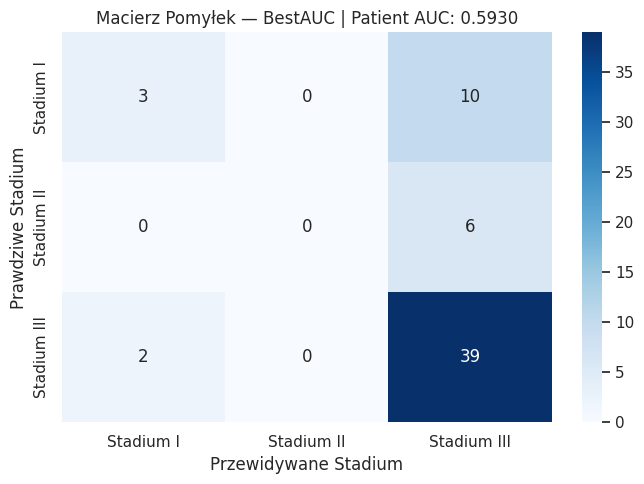

Zapisano: /content/drive/MyDrive/masked_ct_models/softvoting_BestAUC.png

── Soft-voting | Model BestF1 (TTA) ──
PATIENT AUC : 0.6513  (Benchmark: 0.881)
PATIENT F1  : 0.5044
PATIENT ACC : 0.6667
              precision    recall  f1-score   support

   Stadium I     0.3684    0.5385    0.4375        13
  Stadium II     1.0000    0.1667    0.2857         6
 Stadium III     0.8000    0.7805    0.7901        41

    accuracy                         0.6667        60
   macro avg     0.7228    0.4952    0.5044        60
weighted avg     0.7265    0.6667    0.6633        60



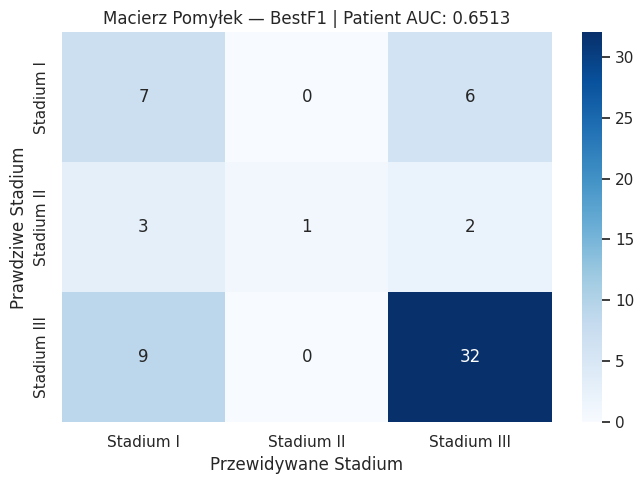

Zapisano: /content/drive/MyDrive/masked_ct_models/softvoting_BestF1.png

──────────────────────────────────────────────────────────────────────
Fold   Model      AUC      F1       Acc      I-F1     II-F1    III-F1
──────────────────────────────────────────────────────────────────────

Fold 1 — n=12 pac. (I=2, II=1, III=9)
  BestAUC    0.8549   0.2857   0.7500   0.0000   0.0000   0.8571
  BestF1     0.8340   0.6944   0.6667   0.3333   1.0000   0.7500

Fold 2 — n=12 pac. (I=3, II=1, III=8)
  BestAUC    0.6211   0.4474   0.7500   0.5000   0.0000   0.8421
  BestF1     0.7319   0.4821   0.7500   0.5714   0.0000   0.8750

Fold 3 — n=12 pac. (I=3, II=1, III=8)
  BestAUC    0.4315   0.4474   0.7500   0.5000   0.0000   0.8421
  BestF1     0.6323   0.3889   0.5833   0.5000   0.0000   0.6667

Fold 4 — n=12 pac. (I=3, II=1, III=8)
  BestAUC    0.4885   0.2667   0.6667   0.0000   0.0000   0.8000
  BestF1     0.4732   0.2456   0.5833   0.0000   0.0000   0.7368

Fold 5 — n=12 pac. (I=2, II=2, III=8)


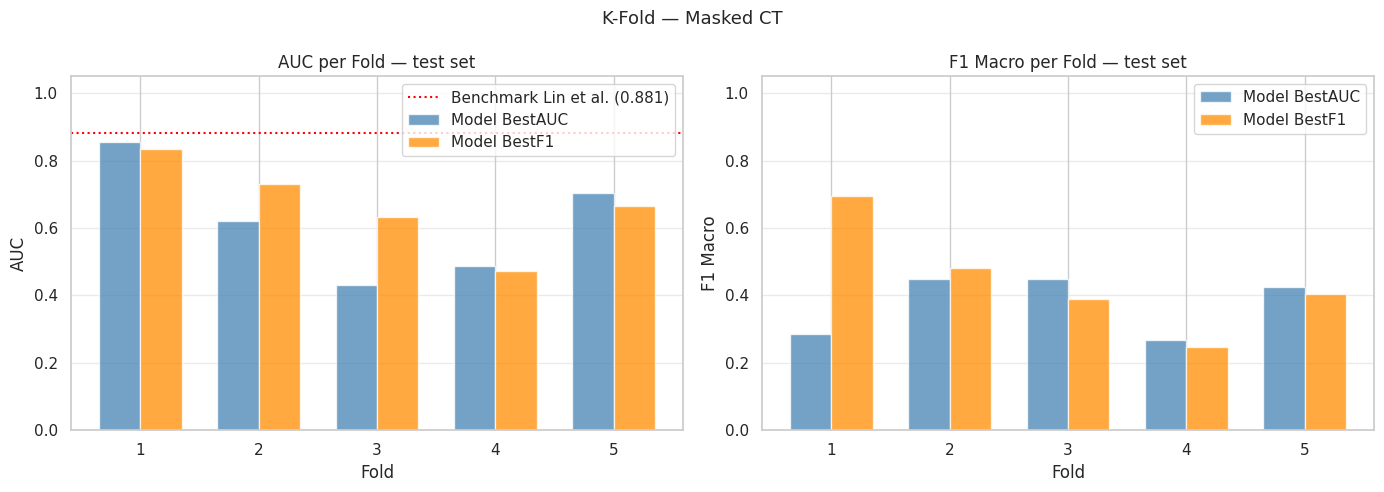

Zapisano: /content/drive/MyDrive/masked_ct_models/kfold_bars.png


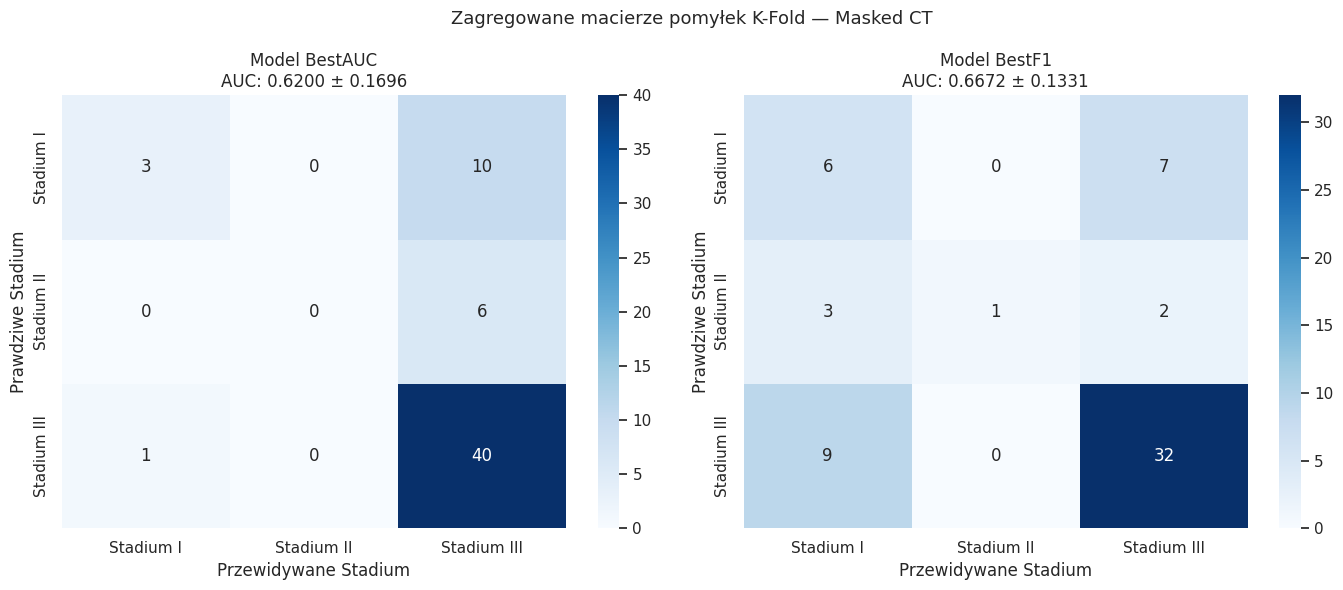

Zapisano: /content/drive/MyDrive/masked_ct_models/kfold_cm.png


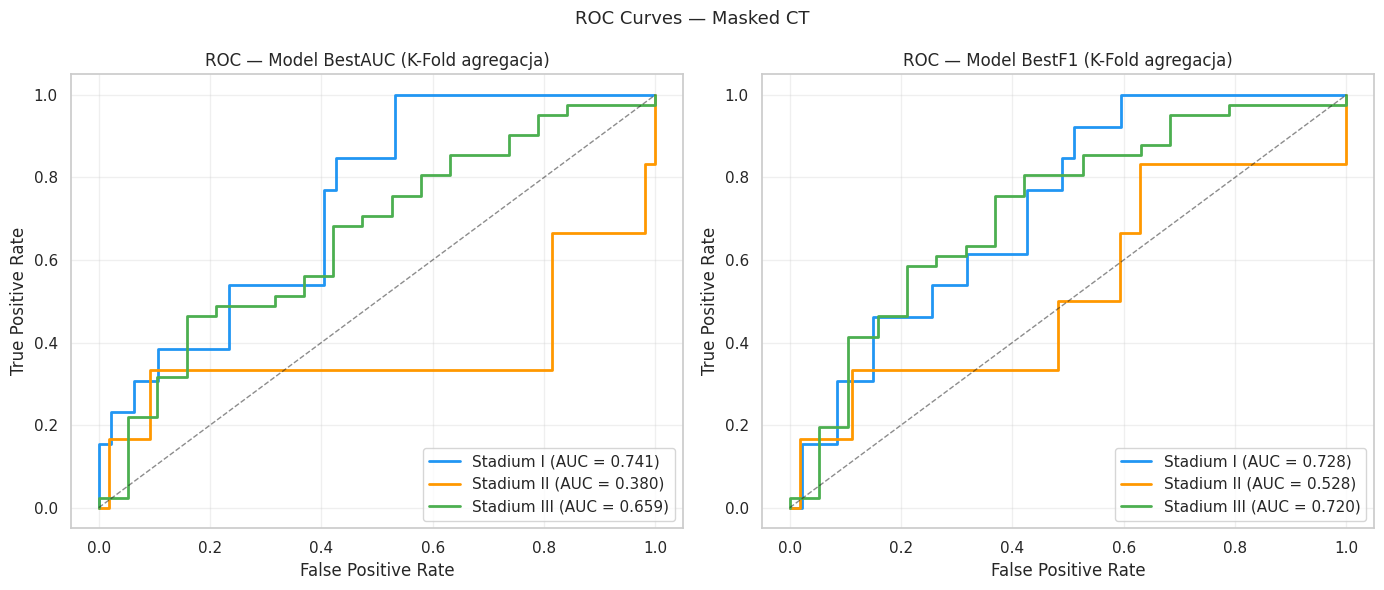

Zapisano: /content/drive/MyDrive/masked_ct_models/kfold_roc.png

══════════════════════════════════════════════════════════════════════
RAPORT KLASYFIKACJI — zagregowane predykcje K-Fold
══════════════════════════════════════════════════════════════════════

Model BestAUC:
              precision    recall  f1-score   support

   Stadium I     0.7500    0.2308    0.3529        13
  Stadium II     0.0000    0.0000    0.0000         6
 Stadium III     0.7143    0.9756    0.8247        41

    accuracy                         0.7167        60
   macro avg     0.4881    0.4021    0.3926        60
weighted avg     0.6506    0.7167    0.6400        60


Model BestF1:
              precision    recall  f1-score   support

   Stadium I     0.3333    0.4615    0.3871        13
  Stadium II     1.0000    0.1667    0.2857         6
 Stadium III     0.7805    0.7805    0.7805        41

    accuracy                         0.6500        60
   macro avg     0.7046    0.4696    0.4844        60
weig

In [34]:
"""
K-FOLD EWALUACJA — v2
Poprawki względem oryginału:
  1. evaluate_fold() przeniesiona POZA run_softvoting() — była wcięta wewnątrz
     funkcji i nigdy nie była wywoływana globalnie (bug strukturalny)
  2. models_to_eval ładuje nowe checkpointy (patient_auc / patient_f1)
  3. Dodana opcja TTA w evaluate_fold()
  4. Podsumowanie zawiera przedział ufności (mean ± std) + globalne ROC curves
  5. Zapis wyników do CSV — przydatny do tabel w pracy magisterskiej
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    classification_report, confusion_matrix,
    roc_curve, auc as sk_auc
)
from sklearn.preprocessing import label_binarize
from torchvision import transforms as T


# ŁADOWANIE MODELI

def load_model(path):
    m = ResNetHybrid(
        num_classes=3,
        dropout_rate=0.4
    ).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m

# DRIVE_SAVE_DIR = '/content/drive/MyDrive/masked_ct_models'
# os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

DRIVE_SAVE_DIR = '/content/drive/MyDrive/masked_ct_models'

models_to_eval = {
    'BestAUC': load_model(f'{DRIVE_SAVE_DIR}/best_masked_focal_patient_auc.pth'),
    'BestF1':  load_model(f'{DRIVE_SAVE_DIR}/best_masked_focal_patient_f1.pth'),
}

target_names = ['Stadium I', 'Stadium II', 'Stadium III']

# PRZYGOTOWANIE LISTY PACJENTÓW Z TEST SETU

df_test_patches  = test_dataset.data_frame.copy()
df_test_patients = (
    df_test_patches
    .groupby('patient_id')['merged_label']
    .first()
    .reset_index()
)
patient_ids    = df_test_patients['patient_id'].values
patient_labels = df_test_patients['merged_label'].values

print(f"Pacjenci w test secie: {len(patient_ids)}")
print(f"Rozkład: I={np.sum(patient_labels==0)}, "
      f"II={np.sum(patient_labels==1)}, "
      f"III={np.sum(patient_labels==2)}")


# EVALUATE_FOLD

def evaluate_fold(model, df_fold, use_tta=False, n_tta=5):
    """
    Ewaluacja modelu na podzbiorze slice'ów df_fold.
    Agregacja do poziomu pacjenta przez soft-voting (mean prawdopodobieństw).
    use_tta=True: każdy slice augmentowany n_tta razy przed agregacją.
    """
    fold_dataset            = LungCancerHybridDataset.__new__(LungCancerHybridDataset)
    fold_dataset.data_frame = df_fold.reset_index(drop=True)
    fold_dataset.root_dir   = IMG_DIR_COLAB
    fold_dataset.transform  = val_test_transforms

    fold_loader = DataLoader(
        fold_dataset, batch_size=32, shuffle=False, num_workers=2
    )

    if use_tta:
        # ── TTA: n_tta przejść, uśrednianie prawdopodobieństw ────────────────
        tta_aug = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
            T.ColorJitter(brightness=0.1, contrast=0.1),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])
        inv_norm = T.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229,       1/0.224,       1/0.225]
        )
        sum_probs  = np.zeros((len(fold_dataset), 3), dtype=np.float64)
        fold_labels = []

        for aug_pass in range(n_tta):
            pass_probs = []
            with torch.no_grad():
                for inputs, clinical, labels in fold_loader:
                    if aug_pass > 0:
                        inputs = torch.stack(
                            [tta_aug(inv_norm(img)) for img in inputs]
                        )
                    inputs   = inputs.to(device)
                    clinical = clinical.to(device)
                    probs    = torch.softmax(model(inputs, clinical), dim=1)
                    pass_probs.extend(probs.cpu().numpy())
                    if aug_pass == 0:
                        fold_labels.extend(labels.cpu().numpy())
            sum_probs += np.array(pass_probs)

        fold_probs  = (sum_probs / n_tta).tolist()

    else:
        # ── Standardowe przejście bez augmentacji ────────────────────────────
        fold_labels, fold_probs = [], []
        with torch.no_grad():
            for inputs, clinical, labels in fold_loader:
                inputs   = inputs.to(device)
                clinical = clinical.to(device)
                probs    = torch.softmax(model(inputs, clinical), dim=1)
                fold_labels.extend(labels.cpu().numpy())
                fold_probs.extend(probs.cpu().numpy())

    # ── Agregacja patient-level ───────────────────────────────────────────────
    df_res = df_fold.copy().reset_index(drop=True)
    df_res['prob_I']     = [p[0] for p in fold_probs]
    df_res['prob_II']    = [p[1] for p in fold_probs]
    df_res['prob_III']   = [p[2] for p in fold_probs]
    df_res['true_label'] = fold_labels

    patient_agg = (
        df_res.groupby('patient_id')
              .agg({'prob_I': 'mean', 'prob_II': 'mean',
                    'prob_III': 'mean', 'true_label': 'first'})
              .reset_index()
    )

    probs_arr = patient_agg[['prob_I', 'prob_II', 'prob_III']].values
    preds_arr = np.argmax(probs_arr, axis=1)
    true_arr  = patient_agg['true_label'].values

    if len(np.unique(true_arr)) < 2:
        return None

    try:
        fold_auc = roc_auc_score(
            true_arr, probs_arr,
            multi_class='ovr', average='macro', labels=[0, 1, 2]
        )
    except ValueError:
        fold_auc = float('nan')

    fold_f1      = f1_score(true_arr, preds_arr, average='macro',
                            labels=[0, 1, 2], zero_division=0)
    fold_acc     = accuracy_score(true_arr, preds_arr)
    per_class_f1 = f1_score(true_arr, preds_arr, average=None,
                             labels=[0, 1, 2], zero_division=0)

    return {
        'auc':   fold_auc,
        'f1':    fold_f1,
        'acc':   fold_acc,
        'f1_I':  per_class_f1[0],
        'f1_II': per_class_f1[1],
        'f1_III':per_class_f1[2],
        'n_I':   int(np.sum(true_arr == 0)),
        'n_II':  int(np.sum(true_arr == 1)),
        'n_III': int(np.sum(true_arr == 2)),
        'true':  true_arr,
        'probs': probs_arr,
    }


# SOFT-VOTING NA PEŁNYM TEST SECIE (przed K-Fold)

def run_softvoting(model, model_name, use_tta=True):
    res = evaluate_fold(model, df_test_patches, use_tta=use_tta)
    if res is None:
        print(f"Model {model_name}: nie można policzyć AUC")
        return

    preds_arr = np.argmax(res['probs'], axis=1)

    print(f"\n── Soft-voting | Model {model_name} {'(TTA)' if use_tta else ''} ──")
    print(f"PATIENT AUC : {res['auc']:.4f}  (Benchmark: 0.881)")
    print(f"PATIENT F1  : {res['f1']:.4f}")
    print(f"PATIENT ACC : {res['acc']:.4f}")
    print(classification_report(res['true'], preds_arr,
                                target_names=target_names,
                                digits=4, zero_division=0))

    cm = confusion_matrix(res['true'], preds_arr)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Macierz Pomyłek — {model_name} | Patient AUC: {res["auc"]:.4f}')
    plt.ylabel('Prawdziwe Stadium')
    plt.xlabel('Przewidywane Stadium')
    plt.tight_layout()
    path = f'{DRIVE_SAVE_DIR}/softvoting_{model_name}.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Zapisano: {path}")

print("\n" + "═"*65)
print("SOFT-VOTING — pełny test set")
print("═"*65)
for name, m in models_to_eval.items():
    run_softvoting(m, name, use_tta=True)

# K-FOLD NA TEST SECIE

USE_TTA   = True    # TTA w K-Fold (można wyłączyć dla szybkości)
N_SPLITS  = 5
skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

all_results = {name: [] for name in models_to_eval}
all_true    = {name: [] for name in models_to_eval}
all_probs   = {name: [] for name in models_to_eval}

print(f"\n{'─'*70}")
print(f"{'Fold':<6} {'Model':<10} {'AUC':<8} {'F1':<8} "
      f"{'Acc':<8} {'I-F1':<8} {'II-F1':<8} {'III-F1'}")
print(f"{'─'*70}")

for fold, (_, test_idx) in enumerate(skf.split(patient_ids, patient_labels)):
    test_patients = set(patient_ids[test_idx])
    df_fold       = df_test_patches[
        df_test_patches['patient_id'].isin(test_patients)
    ].copy()

    n_I   = int(np.sum(patient_labels[test_idx] == 0))
    n_II  = int(np.sum(patient_labels[test_idx] == 1))
    n_III = int(np.sum(patient_labels[test_idx] == 2))
    print(f"\nFold {fold+1} — n={len(test_patients)} pac. "
          f"(I={n_I}, II={n_II}, III={n_III})")

    for name, model in models_to_eval.items():
        res = evaluate_fold(model, df_fold, use_tta=USE_TTA)
        if res is None:
            print(f"  {name:<10} POMINIĘTY — za mało klas w foldzie")
            continue

        res['fold'] = fold + 1
        all_results[name].append(res)
        all_true[name].extend(res['true'].tolist())
        all_probs[name].extend(res['probs'].tolist())

        print(f"  {name:<10} {res['auc']:<8.4f} {res['f1']:<8.4f} "
              f"{res['acc']:<8.4f} {res['f1_I']:<8.4f} "
              f"{res['f1_II']:<8.4f} {res['f1_III']:.4f}")


# PODSUMOWANIE — mean ± std

print(f"\n{'═'*70}")
print("PODSUMOWANIE K-FOLD — mean ± std (Patient Level)")
print(f"{'═'*70}")

summary_rows = []

for name in models_to_eval:
    if not all_results[name]:
        continue
    df_res = pd.DataFrame(all_results[name])
    print(f"\nModel {name}:")
    row = {'model': name}
    for metric in ['auc', 'f1', 'acc', 'f1_I', 'f1_II', 'f1_III']:
        vals = df_res[metric].dropna()
        mean, std = vals.mean(), vals.std()
        print(f"  {metric.upper():<10}: {mean:.4f} ± {std:.4f}   "
              f"[min={vals.min():.4f}, max={vals.max():.4f}]")
        row[f'{metric}_mean'] = round(mean, 4)
        row[f'{metric}_std']  = round(std, 4)
    summary_rows.append(row)

# Zapis do CSV — gotowe do tabeli w pracy
df_summary = pd.DataFrame(summary_rows)
csv_path   = f'{DRIVE_SAVE_DIR}/kfold_summary.csv'
df_summary.to_csv(csv_path, index=False)
print(f"\nPodsumowanie zapisane: {csv_path}")

print(f"\n{'─'*70}")
print("WYNIK REFERENCYJNY — pełny test set (bez podziału na foldy):")
for name, model in models_to_eval.items():
    res = evaluate_fold(model, df_test_patches, use_tta=USE_TTA)
    if res:
        print(f"  Model {name}: AUC={res['auc']:.4f} | "
              f"F1={res['f1']:.4f} | Acc={res['acc']:.4f}")


# WIZUALIZACJE

# ── 1. AUC i F1 per fold (słupkowy) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'BestAUC': 'steelblue', 'BestF1': 'darkorange'}
x     = np.arange(1, N_SPLITS + 1)
width = 0.35

for ax, metric, ylabel in zip(axes, ['auc', 'f1'], ['AUC', 'F1 Macro']):
    for i, (name, color) in enumerate(colors.items()):
        vals = [r[metric] for r in all_results[name]]
        offset = (i - 0.5) * width
        ax.bar(x + offset, vals, width, color=color, alpha=0.75, label=f'Model {name}')
    if metric == 'auc':
        ax.axhline(0.881, color='red', linestyle=':', linewidth=1.5,
                   label='Benchmark Lin et al. (0.881)')
    ax.set_xlabel('Fold')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} per Fold — test set')
    ax.set_xticks(x)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('K-Fold — Masked CT', fontsize=13)
plt.tight_layout()
path = f'{DRIVE_SAVE_DIR}/kfold_bars.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Zapisano: {path}")

# ── 2. Macierze pomyłek (zagregowane przez wszystkie foldy) ───────────────────
fig, axes = plt.subplots(1, len(models_to_eval), figsize=(7 * len(models_to_eval), 6))
if len(models_to_eval) == 1:
    axes = [axes]

for ax, (name, _) in zip(axes, models_to_eval.items()):
    if not all_true[name]:
        ax.set_visible(False)
        continue
    true_arr  = np.array(all_true[name])
    probs_arr = np.array(all_probs[name])
    preds_arr = np.argmax(probs_arr, axis=1)
    cm        = confusion_matrix(true_arr, preds_arr, labels=[0, 1, 2])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Przewidywane Stadium')
    ax.set_ylabel('Prawdziwe Stadium')

    df_res   = pd.DataFrame(all_results[name])
    mean_auc = df_res['auc'].mean()
    std_auc  = df_res['auc'].std()
    ax.set_title(f'Model {name}\nAUC: {mean_auc:.4f} ± {std_auc:.4f}')

plt.suptitle('Zagregowane macierze pomyłek K-Fold — Masked CT', fontsize=13)
plt.tight_layout()
path = f'{DRIVE_SAVE_DIR}/kfold_cm.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Zapisano: {path}")

# ── 3. ROC curves (na zagregowanych predykcjach ze wszystkich foldów) ─────────
fig, axes = plt.subplots(1, len(models_to_eval), figsize=(7 * len(models_to_eval), 6))
if len(models_to_eval) == 1:
    axes = [axes]

class_colors = ['#2196F3', '#FF9800', '#4CAF50']

for ax, (name, _) in zip(axes, models_to_eval.items()):
    if not all_true[name]:
        ax.set_visible(False)
        continue

    true_arr  = np.array(all_true[name])
    probs_arr = np.array(all_probs[name])
    true_bin  = label_binarize(true_arr, classes=[0, 1, 2])

    for cls_idx, (cls_name, color) in enumerate(zip(target_names, class_colors)):
        fpr, tpr, _ = roc_curve(true_bin[:, cls_idx], probs_arr[:, cls_idx])
        roc_auc     = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{cls_name} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — Model {name} (K-Fold agregacja)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — Masked CT', fontsize=13)
plt.tight_layout()
path = f'{DRIVE_SAVE_DIR}/kfold_roc.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Zapisano: {path}")

# ── 4. Raport klasyfikacji (zagregowany) ──────────────────────────────────────
print(f"\n{'═'*70}")
print("RAPORT KLASYFIKACJI — zagregowane predykcje K-Fold")
print(f"{'═'*70}")
for name in models_to_eval:
    if not all_true[name]:
        continue
    true_arr  = np.array(all_true[name])
    probs_arr = np.array(all_probs[name])
    preds_arr = np.argmax(probs_arr, axis=1)
    print(f"\nModel {name}:")
    print(classification_report(true_arr, preds_arr,
                                target_names=target_names,
                                digits=4, zero_division=0))

Grad-cam

Znaleziono przykłady dla klas: [2, 0, 1]


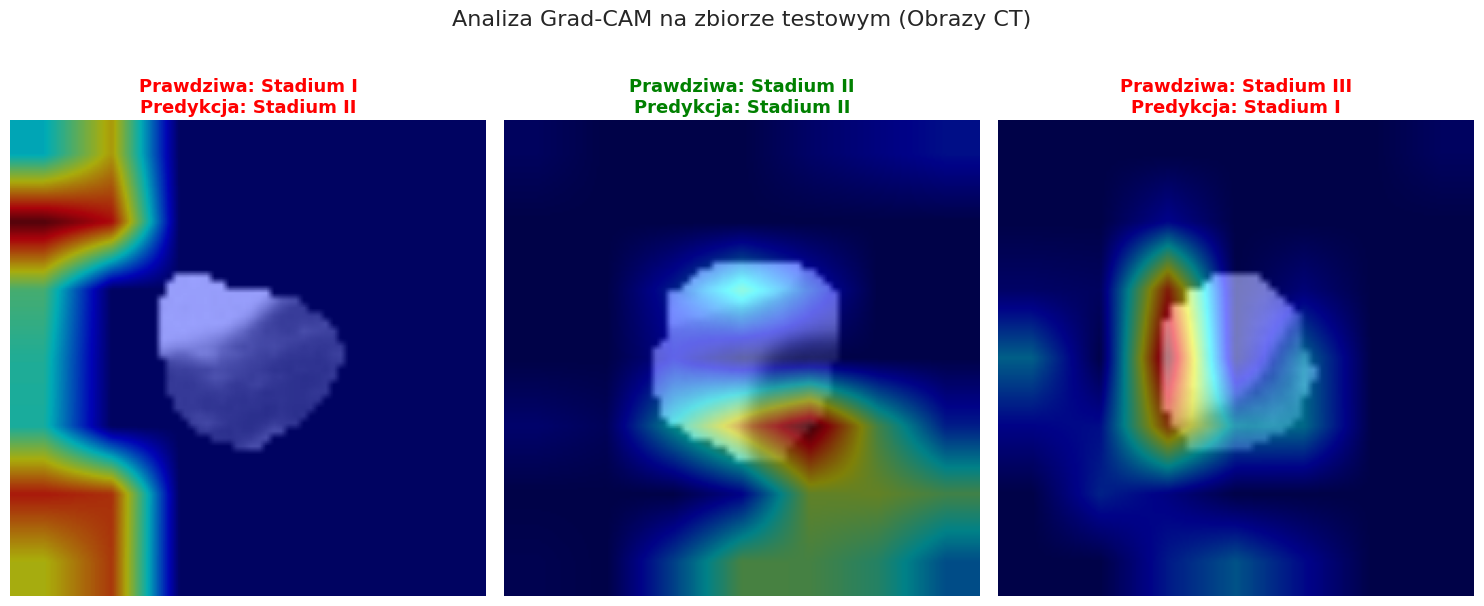

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


class HybridModelWrapper(torch.nn.Module):
    def __init__(self, model, clinical_data):
        super(HybridModelWrapper, self).__init__()
        self.model = model
        self.clinical_data = clinical_data

    def forward(self, x):
        return self.model(x, self.clinical_data)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

target_layers = [model.backbone.layer4[-1]]
target_names = ['Stadium I', 'Stadium II', 'Stadium III']

examples = {}

for inputs, clinical, labels in test_loader: # ZMIEŃ na test_loader, jeśli masz
    for i in range(len(labels)):
        class_idx = labels[i].item()

        if class_idx not in examples:
            examples[class_idx] = (inputs[i].detach(), clinical[i].detach())

        if len(examples) == 3:
            break
    if len(examples) == 3:
        break

print(f"Znaleziono przykłady dla klas: {list(examples.keys())}")

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Analiza Grad-CAM na zbiorze testowym (Obrazy CT)', fontsize=16, y=1.05)

for class_idx in range(3):
    img_tensor, clin_tensor = examples[class_idx]

    img_tensor = img_tensor.unsqueeze(0).to(device)
    clin_tensor = clin_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor, clin_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()

    wrapped_model = HybridModelWrapper(model, clin_tensor)

    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    targets = [ClassifierOutputTarget(class_idx)]

    # Generowanie mapy ciepła
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    rgb_img = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min()) # Skalowanie 0-1

    # Nałożenie mapy ciepła na oryginalny obraz
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    ax = axes[class_idx]
    ax.imshow(cam_image)

    # Zmiana koloru tytułu: Zielony jeśli trafił, Czerwony jeśli się pomylił
    color = 'green' if class_idx == pred_idx else 'red'

    ax.set_title(f"Prawdziwa: {target_names[class_idx]}\nPredykcja: {target_names[pred_idx]}",
                 fontsize=13, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/final_hybrid_gradcam_test_dual_manual.png', dpi=300, bbox_inches='tight')
plt.show()

Kalibracja progów


KALIBRACJA PROGÓW — Model BestAUC
Kalibracja progów na zbiorze walidacyjnym...
Optymalne progi:
  Stadium I:   0.60
  Stadium II:  0.50
  Stadium III: 1.00 (Baza)

--- PRZED TUNINGIEM ---
              precision    recall  f1-score   support

   Stadium I       0.50      0.15      0.24        13
  Stadium II       0.00      0.00      0.00         6
 Stadium III       0.70      0.95      0.80        41

    accuracy                           0.68        60
   macro avg       0.40      0.37      0.35        60
weighted avg       0.58      0.68      0.60        60

--- PO TUNINGU ---
              precision    recall  f1-score   support

   Stadium I       0.38      0.62      0.47        13
  Stadium II       0.50      0.17      0.25         6
 Stadium III       0.78      0.71      0.74        41

    accuracy                           0.63        60
   macro avg       0.55      0.50      0.49        60
weighted avg       0.67      0.63      0.64        60



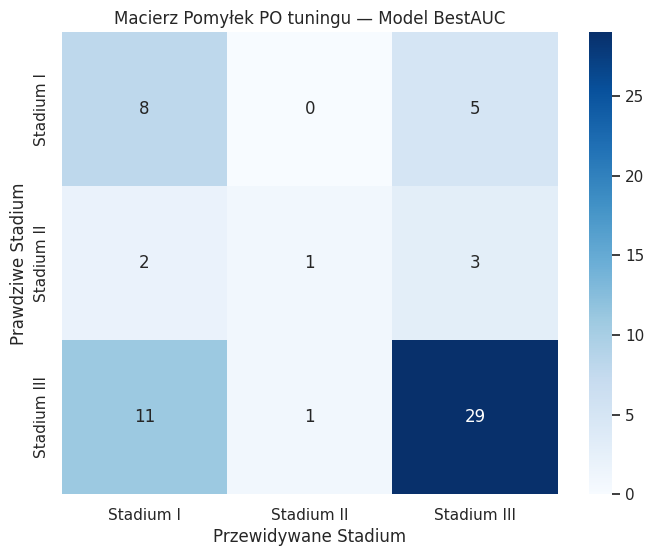

Zapisano: /content/drive/MyDrive/masked_ct_models/calibration_BestAUC_tr12.png

KALIBRACJA PROGÓW — Model BestF1
Kalibracja progów na zbiorze walidacyjnym...
Optymalne progi:
  Stadium I:   0.90
  Stadium II:  0.90
  Stadium III: 1.00 (Baza)

--- PRZED TUNINGIEM ---
              precision    recall  f1-score   support

   Stadium I       0.38      0.46      0.41        13
  Stadium II       1.00      0.33      0.50         6
 Stadium III       0.76      0.78      0.77        41

    accuracy                           0.67        60
   macro avg       0.71      0.53      0.56        60
weighted avg       0.70      0.67      0.67        60

--- PO TUNINGU ---
              precision    recall  f1-score   support

   Stadium I       0.37      0.54      0.44        13
  Stadium II       0.67      0.33      0.44         6
 Stadium III       0.76      0.71      0.73        41

    accuracy                           0.63        60
   macro avg       0.60      0.53      0.54        60
weighte

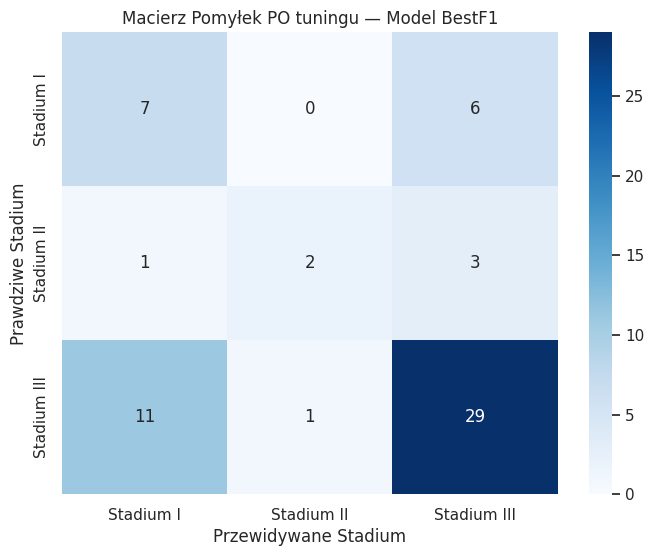

Zapisano: /content/drive/MyDrive/masked_ct_models/calibration_BestF1_tr12.png


In [36]:
def calibrate_thresholds(model, model_name):
    print(f"\n{'='*60}")
    print(f"KALIBRACJA PROGÓW — Model {model_name}")
    print(f"{'='*60}")

    # Predykcje na zbiorze walidacyjnym
    df_val_patches = val_dataset.data_frame.copy()
    val_results    = evaluate_fold(model, df_val_patches)
    val_probs      = val_results['probs']
    val_true       = val_results['true']

    # Predykcje na zbiorze testowym
    test_results = evaluate_fold(model, df_test_patches)
    test_probs   = test_results['probs']
    test_true    = test_results['true']

    # Kalibracja na zbiorze walidacyjnym
    best_f1         = 0.0
    best_thresholds = [1.0, 1.0, 1.0]
    thresholds_range = np.arange(0.1, 1.05, 0.05)

    print("Kalibracja progów na zbiorze walidacyjnym...")
    for t0 in thresholds_range:
        for t1 in thresholds_range:
            current_thresholds = np.array([t0, t1, 1.0])
            adjusted_probs     = val_probs / current_thresholds
            preds              = np.argmax(adjusted_probs, axis=1)
            f1                 = f1_score(val_true, preds, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1         = f1
                best_thresholds = current_thresholds

    print(f"Optymalne progi:")
    print(f"  Stadium I:   {best_thresholds[0]:.2f}")
    print(f"  Stadium II:  {best_thresholds[1]:.2f}")
    print(f"  Stadium III: {best_thresholds[2]:.2f} (Baza)")

    # Ewaluacja na test secie
    base_preds     = np.argmax(test_probs, axis=1)
    adjusted_probs = test_probs / best_thresholds
    tuned_preds    = np.argmax(adjusted_probs, axis=1)

    print(f"\n--- PRZED TUNINGIEM ---")
    print(classification_report(test_true, base_preds,
                                target_names=target_names, zero_division=0))

    print(f"--- PO TUNINGU ---")
    print(classification_report(test_true, tuned_preds,
                                target_names=target_names, zero_division=0))

    cm = confusion_matrix(test_true, tuned_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Macierz Pomyłek PO tuningu — Model {model_name}')
    plt.ylabel('Prawdziwe Stadium')
    plt.xlabel('Przewidywane Stadium')
    save_path = f'{DRIVE_SAVE_DIR}/calibration_{model_name}_tr12.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Zapisano: {save_path}")

    return best_thresholds, test_true, base_preds, tuned_preds

for name, model in models_to_eval.items():
    calibrate_thresholds(model, name)